# Experiment 1 — Match Intensity Prediction

**Research question:** Can we predict match-day performance from morning training state? Is match intensity a viable causal target for optimising training load?

**Target:** `Match Intensity Yesterday` (continuous, range [0, ∞))
**Covariates:** 8 morning-assessment variables (wellness composites, ACWR, GPS load, Player ID)
**Models:** Ridge Regression, XGBoost (GPU), CatBoost (GPU), TabPFN (GPU)

---

### Table of Contents

| Section | Content |
|---------|---------|
| **0. Imports & Configuration** | Libraries, experiment runner, covariates, lags |
| **1. Diagnostic EDA** | Dataset scope, target distribution, feature correlations, player/position effects, train/test shift |
| **2. Experiment A — Raw Match Intensity** | All 4 models × 10 lags, comparison table, RMSE/R² charts, actual vs predicted, feature importance |
| **3. Experiment B — Personal Deviation** | Remove player fixed effects, predict within-player deviations, verify no residual signal |
| **4. Summary** | Raw results table (no interpretations) |


---
## Configuration — edit this cell to change the experiment

All settings for this notebook are centralised here.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

# ── Project path ─────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from scripts.Experiment1 import run_experiment

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# ── Covariates ────────────────────────────────────────────────────────────────
# All variables available at morning-assessment time + Player ID.
#
# Player ID encoding (important):
#   'Player ID' stores integer IDs 1-28 in the raw data, but player 4 is NOT
#   twice player 2 — the integers are nominal labels, not ordinal numbers.
#   data_loader.py classifies 'Player ID' in known_categorical, so it is:
#     - One-hot encoded (28 binary columns) for Ridge Regression → player-specific
#       intercepts, the correct representation for a linear model.
#     - Label encoded (0-27 integers) + passed as cat_feature for CatBoost →
#       CatBoost handles this natively without any ordinal assumption.
#     - Label encoded for XGBoost → tree splits are non-monotone and can
#       effectively partition the 28 IDs into groups; ordinal assumption is NOT
#       used by the splitting algorithm (it's a limitation, not a catastrophic error).
#     - Label encoded for TabPFN in run_experiment calls; but in the § 6 direct
#       TabPFN analysis (cell-16) we use one-hot + drop redundant lag copies.
#
# Since Player ID is static (never changes for a player), lagged copies of
# it are always identical. Tree models assign near-zero importance to the
# duplicates; Ridge's L2 penalty distributes the coefficient equally across
# the collinear lag copies (sum equals the true player effect).

COVARIATES = [
    # Morning wellness composites
    'Physical State',                        # Morning composite: fatigue/soreness/readiness
    'Mental State',                          # Morning composite: mood/stress/sleep
    # Yesterday's training
    'Training Intensity Yesterday',                
    # Yesterday's load -- ACWR ratios
    'Total Distance (ACWR) Yesterday',       # Workload: ACWR total distance
    'High Speed Distance (ACWR) Yesterday',  # Workload: ACWR high-speed distance
    'Any ACWR Danger',                       # Binary: any ACWR > 1.5
    # Yesterday's load -- GPS benchmark %
    'Total Distance % Yesterday',            # GPS total distance as % of match benchmark
    'High Speed Distance % Yesterday',       # GPS high-speed distance as % of match benchmark
    # Yesterday's load -- subjective
    'Perceived Exertion Yesterday',          # RPE z-score
    # Yesterday's raw GPS/HR
    'Total Minutes Yesterday',               # Raw session volume
    'Avg Heart Rate Yesterday',              # Average heart rate
    'Heart Rate Exertion Yesterday',         # Heart rate exertion index
    # Player profile
    'Player ID',                             # Nominal player identifier
]

# Lags 1–10: each step adds one extra day of history per player
LAGS = list(range(1, 11))

# --- GPU overrides (same pattern as Experiment2 / Experiment3) --------
# Set device to "cpu" / "CPU" if no CUDA GPU is available.
GPU_OVERRIDES = {
    'xgboost':  {'device': 'cuda'},
    'catboost': {'task_type': 'GPU'},
    'tabpfn':   {'device': 'cuda', 'ignore_pretraining_limits': True},
}

# Colour palette per model
MODEL_PALETTE = {
    'LinReg':   'steelblue',
    'XGBoost':  'darkorange',
    'CatBoost': 'seagreen',
    'TabPFN':   'mediumpurple',
}

# ── Helper: compact results DataFrame ────────────────────────────────────────
def results_table(all_results: dict) -> pd.DataFrame:
    """Convert {lag: results_dict} into a summary DataFrame."""
    rows = []
    for lag, r in all_results.items():
        m = r['metrics']
        rows.append({
            'Lag': lag,
            'RMSE': round(m['rmse'], 4),
            'Null RMSE': round(m['null_rmse'], 4),
            'Train RMSE': round(m['train_rmse'], 4),
            'R²': round(m['r2'], 4),
            'Pearson r': round(m['pearson_r'], 4),
            'MAE': round(m['mae'], 4),
            'N test': m['n_test'],
        })
    return pd.DataFrame(rows).set_index('Lag')

print(f'Project root: {PROJECT_ROOT}')
print(f'Covariates ({len(COVARIATES)}): {COVARIATES}')
print(f'Lags: {LAGS}')
print()
print('Player ID encoding:')
print('  LinReg  → one-hot (28 binary columns) — correct linear player intercepts')
print('  CatBoost → label + cat_feature       — natively nominal')
print('  XGBoost  → label (0-27)               — non-monotone tree splits, acceptable')
print('  TabPFN   → one-hot in § 6 analysis, label otherwise')





Project root: C:\Users\U0152019\PhD Documents\Projects\2. Readiness To Train\Readiness-To-Train
Covariates (13): ['Physical State', 'Mental State', 'Training Intensity Yesterday', 'Total Distance (ACWR) Yesterday', 'High Speed Distance (ACWR) Yesterday', 'Any ACWR Danger', 'Total Distance % Yesterday', 'High Speed Distance % Yesterday', 'Perceived Exertion Yesterday', 'Total Minutes Yesterday', 'Avg Heart Rate Yesterday', 'Heart Rate Exertion Yesterday', 'Player ID']
Lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Player ID encoding:
  LinReg  → one-hot (28 binary columns) — correct linear player intercepts
  CatBoost → label + cat_feature       — natively nominal
  XGBoost  → label (0-27)               — non-monotone tree splits, acceptable
  TabPFN   → one-hot in § 6 analysis, label otherwise


---
## 1. Diagnostic EDA

Before running any model, we analyse the prediction task to understand its difficulty.


Dataset shape:             (5234, 48)
Date range:                2025-07-27 → 2026-02-17
Unique players:            28
Total rows:                5,234
Match-event rows (MI≠NaN): 362  (6.9% of all rows)
Unique match dates:        25

Match Intensity Yesterday: mean=3.412, std=1.165, min=1.075, max=7.110


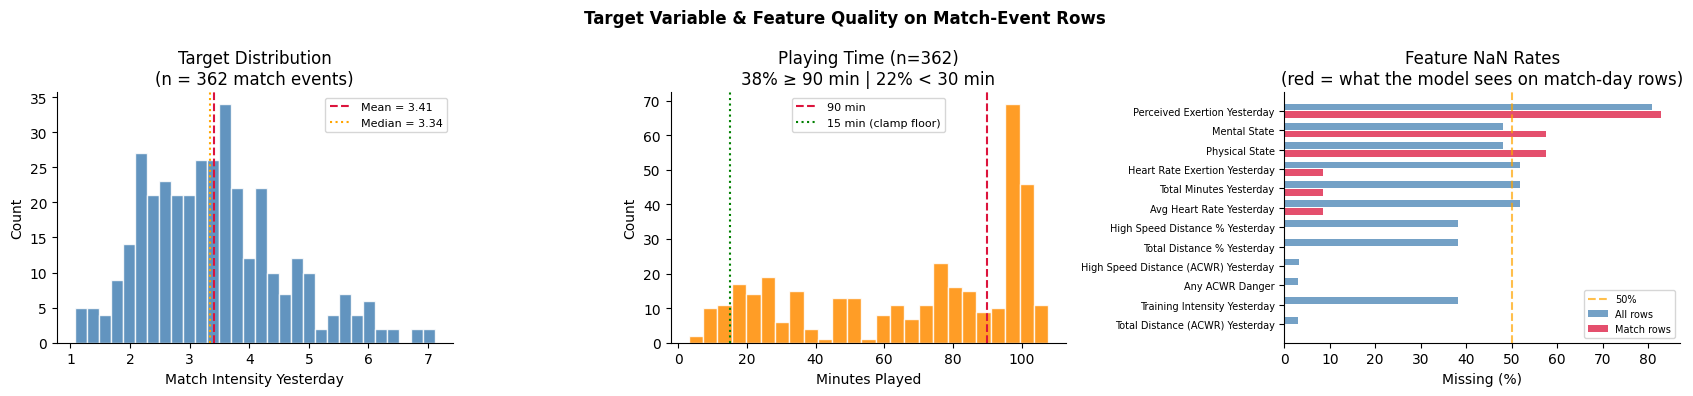


=== Feature NaN Rates ===
                                      All rows  Match rows
Total Distance (ACWR) Yesterday            3.0         0.0
Training Intensity Yesterday              38.2         0.0
Any ACWR Danger                            3.0         0.0
High Speed Distance (ACWR) Yesterday       3.3         0.0
Total Distance % Yesterday                38.2         0.0
High Speed Distance % Yesterday           38.2         0.0
Avg Heart Rate Yesterday                  51.9         8.6
Total Minutes Yesterday                   51.9         8.6
Heart Rate Exertion Yesterday             51.9         8.6
Physical State                            48.2        57.5
Mental State                              48.2        57.5
Perceived Exertion Yesterday              80.8        82.9


In [2]:
# ── EDA Part 1: Dataset scope, target distribution, playing time, NaN rates ──
RTT_PATH = PROJECT_ROOT / 'data' / 'processed' / 'RTT.xlsx'
df = pd.read_excel(RTT_PATH)
df['Date'] = pd.to_datetime(df['Date'])

match_rows = df[df['Match Intensity Yesterday'].notna()].copy()
mi = df['Match Intensity Yesterday'].dropna()

print(f'Dataset shape:             {df.shape}')
print(f'Date range:                {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Unique players:            {df["Player ID"].nunique()}')
print(f'Total rows:                {len(df):,}')
print(f'Match-event rows (MI≠NaN): {len(match_rows):,}  ({100*len(match_rows)/len(df):.1f}% of all rows)')
print(f'Unique match dates:        {match_rows["Date"].nunique()}')
print(f'\nMatch Intensity Yesterday: mean={mi.mean():.3f}, std={mi.std():.3f}, '
      f'min={mi.min():.3f}, max={mi.max():.3f}')

# ── Figure 1: Target distribution | Playing time | NaN rates ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Target Variable & Feature Quality on Match-Event Rows',
             fontsize=12, fontweight='bold')

# 1a: Target distribution
ax = axes[0]
ax.hist(mi.values, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(mi.mean(),   color='crimson', linestyle='--', lw=1.5, label=f'Mean = {mi.mean():.2f}')
ax.axvline(mi.median(), color='orange',  linestyle=':',  lw=1.5, label=f'Median = {mi.median():.2f}')
ax.set_xlabel('Match Intensity Yesterday')
ax.set_ylabel('Count')
ax.set_title(f'Target Distribution\n(n = {len(mi)} match events)')
ax.legend(fontsize=8)

# 1b: Playing time distribution
ax = axes[1]
if 'Match Minutes Played Yesterday' in df.columns:
    mins = match_rows['Match Minutes Played Yesterday'].dropna()
    ax.hist(mins.values, bins=25, color='darkorange', edgecolor='white', alpha=0.85)
    ax.axvline(90, color='crimson', linestyle='--', lw=1.5, label='90 min')
    ax.axvline(15, color='green',   linestyle=':',  lw=1.5, label='15 min (clamp floor)')
    full_90 = (mins >= 90).mean() * 100
    sub30   = (mins < 30).mean()  * 100
    ax.set_xlabel('Minutes Played')
    ax.set_ylabel('Count')
    ax.set_title(f'Playing Time (n={len(mins)})\n{full_90:.0f}% ≥ 90 min | {sub30:.0f}% < 30 min')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'Column not found', ha='center', va='center', transform=ax.transAxes)

# 1c: NaN rates — all rows vs match-event rows only
# Exclude 'Player ID' from NaN analysis (always present)
cov_for_nan = [c for c in COVARIATES if c != 'Player ID']
ax = axes[2]
nan_all   = {c: df[c].isna().mean()*100        for c in cov_for_nan if c in df.columns}
nan_match = {c: match_rows[c].isna().mean()*100 for c in cov_for_nan if c in df.columns}
nan_df = pd.DataFrame({'All rows': nan_all, 'Match rows': nan_match}).sort_values('Match rows', ascending=True)
y_pos = np.arange(len(nan_df))
ax.barh(y_pos + 0.2, nan_df['All rows'],   0.35, label='All rows',   color='steelblue', alpha=0.75)
ax.barh(y_pos - 0.2, nan_df['Match rows'], 0.35, label='Match rows', color='crimson',   alpha=0.75)
ax.set_yticks(y_pos)
ax.set_yticklabels(nan_df.index, fontsize=7)
ax.axvline(50, color='orange', linestyle='--', alpha=0.7, label='50%')
ax.set_xlabel('Missing (%)')
ax.set_title('Feature NaN Rates\n(red = what the model sees on match-day rows)')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print('\n=== Feature NaN Rates ===')
print(nan_df.round(1).to_string())


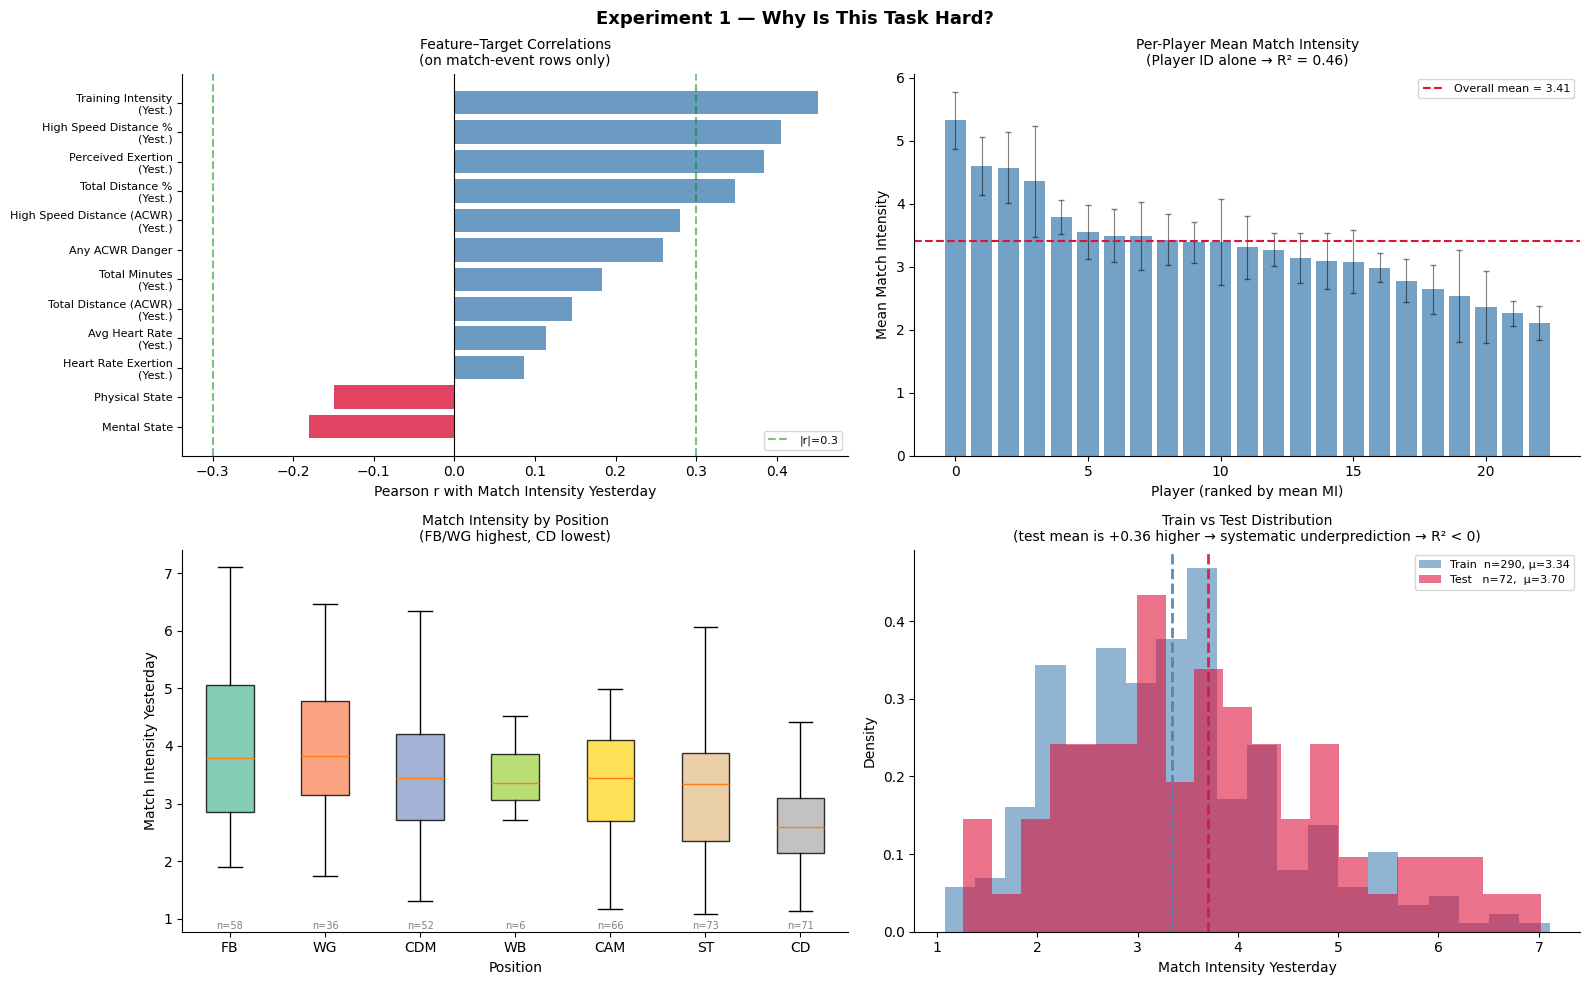


=== Root Cause Summary ===
1. Physical State NaN on match rows:       57%
   Mental State NaN on match rows:         57%
   Perceived Exertion NaN on match rows:   83%
2. Best feature correlation (abs):         |r| = 0.451  (Training Intensity Yesterday)
3. Player fixed-effect R²:                 0.455
4. Train/test mean shift:                  +0.363 MI units  (test is higher)
5. Test set: 5 match dates out of 25 total


In [3]:
# ── EDA Part 2: Correlations | Player effects | Position | Distribution shift ─
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Experiment 1 — Why Is This Task Hard?', fontsize=13, fontweight='bold')

# 2a: Feature–target correlations on match-event rows
ax = axes[0, 0]
cov_for_corr = [c for c in COVARIATES if c != 'Player ID']
corrs = {}
for col in cov_for_corr:
    if col in match_rows.columns:
        sub = match_rows[['Match Intensity Yesterday', col]].dropna()
        if len(sub) > 5:
            corrs[col] = sub['Match Intensity Yesterday'].corr(sub[col])
corr_s = pd.Series(corrs).sort_values()
bar_colors = ['crimson' if v < 0 else 'steelblue' for v in corr_s.values]
ax.barh(range(len(corr_s)), corr_s.values, color=bar_colors, alpha=0.8)
ax.set_yticks(range(len(corr_s)))
ax.set_yticklabels([c.replace(' Yesterday', '\n(Yest.)') for c in corr_s.index], fontsize=8)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(0.3,  color='green', linestyle='--', alpha=0.5, label='|r|=0.3')
ax.axvline(-0.3, color='green', linestyle='--', alpha=0.5)
ax.set_xlabel('Pearson r with Match Intensity Yesterday')
ax.set_title('Feature–Target Correlations\n(on match-event rows only)', fontsize=10)
ax.legend(fontsize=8)

# 2b: Per-player mean match intensity — player fixed effects
ax = axes[0, 1]
p_agg = match_rows.groupby('Player ID')['Match Intensity Yesterday'].agg(['mean', 'std', 'count'])
p_agg = p_agg.sort_values('mean', ascending=False)
se = p_agg['std'] / np.sqrt(p_agg['count'])
ax.bar(range(len(p_agg)), p_agg['mean'].values, color='steelblue', alpha=0.75)
ax.errorbar(range(len(p_agg)), p_agg['mean'].values, yerr=1.96 * se.values,
            fmt='none', color='black', alpha=0.5, capsize=2, lw=0.8)
overall_mean = match_rows['Match Intensity Yesterday'].mean()
ax.axhline(overall_mean, color='crimson', linestyle='--', lw=1.5,
           label=f'Overall mean = {overall_mean:.2f}')
# Compute R² from player identity alone
player_mean_map = p_agg['mean'].to_dict()
y_true_all = match_rows['Match Intensity Yesterday'].values
y_hat_player = match_rows['Player ID'].map(player_mean_map).values
valid = ~np.isnan(y_hat_player)
ss_res = np.sum((y_true_all[valid] - y_hat_player[valid]) ** 2)
ss_tot = np.sum((y_true_all[valid] - y_true_all[valid].mean()) ** 2)
r2_player = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
ax.set_xlabel('Player (ranked by mean MI)')
ax.set_ylabel('Mean Match Intensity')
ax.set_title(f'Per-Player Mean Match Intensity\n(Player ID alone → R² = {r2_player:.2f})', fontsize=10)
ax.legend(fontsize=8)

# 2c: Position effect
ax = axes[1, 0]
if 'Position' in match_rows.columns:
    pos_data = match_rows.dropna(subset=['Position', 'Match Intensity Yesterday'])
    pos_means = pos_data.groupby('Position')['Match Intensity Yesterday'].mean().sort_values(ascending=False)
    pos_order = pos_means.index.tolist()
    pos_vals = [pos_data[pos_data['Position'] == p]['Match Intensity Yesterday'].values for p in pos_order]
    bp = ax.boxplot(pos_vals, labels=pos_order, patch_artist=True)
    palette = plt.cm.Set2(np.linspace(0, 1, len(pos_order)))
    for patch, c in zip(bp['boxes'], palette):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax.set_xlabel('Position')
    ax.set_ylabel('Match Intensity Yesterday')
    ax.set_title('Match Intensity by Position\n(FB/WG highest, CD lowest)', fontsize=10)
    for i, pos in enumerate(pos_order):
        n = (pos_data['Position'] == pos).sum()
        ax.text(i + 1, ax.get_ylim()[0] + 0.05, f'n={n}', ha='center', fontsize=7, color='grey')

# 2d: Train vs test distribution shift
ax = axes[1, 1]
match_dates_sorted = sorted(match_rows['Date'].unique())
n_test_dates = max(1, int(len(match_dates_sorted) * 0.2))
test_dates = set(match_dates_sorted[-n_test_dates:])
train_mi = match_rows[~match_rows['Date'].isin(test_dates)]['Match Intensity Yesterday'].dropna()
test_mi  = match_rows[ match_rows['Date'].isin(test_dates)]['Match Intensity Yesterday'].dropna()
ax.hist(train_mi.values, bins=20, alpha=0.6, color='steelblue', density=True,
        label=f'Train  n={len(train_mi)}, μ={train_mi.mean():.2f}')
ax.hist(test_mi.values,  bins=20, alpha=0.6, color='crimson',   density=True,
        label=f'Test   n={len(test_mi)},  μ={test_mi.mean():.2f}')
ax.axvline(train_mi.mean(), color='steelblue', linestyle='--', lw=2, alpha=0.9)
ax.axvline(test_mi.mean(),  color='crimson',   linestyle='--', lw=2, alpha=0.9)
shift = test_mi.mean() - train_mi.mean()
ax.set_xlabel('Match Intensity Yesterday')
ax.set_ylabel('Density')
ax.set_title(
    f'Train vs Test Distribution\n(test mean is {shift:+.2f} higher → systematic underprediction → R² < 0)',
    fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\n=== Root Cause Summary ===')
print(f'1. Physical State NaN on match rows:       {nan_match.get("Physical State", 0):.0f}%')
print(f'   Mental State NaN on match rows:         {nan_match.get("Mental State", 0):.0f}%')
print(f'   Perceived Exertion NaN on match rows:   {nan_match.get("Perceived Exertion Yesterday", 0):.0f}%')
print(f'2. Best feature correlation (abs):         |r| = {corr_s.abs().max():.3f}  ({corr_s.abs().idxmax()})')
print(f'3. Player fixed-effect R²:                 {r2_player:.3f}')
print(f'4. Train/test mean shift:                  {shift:+.3f} MI units  (test is higher)')
print(f'5. Test set: {n_test_dates} match dates out of {len(match_dates_sorted)} total')


---
## 2. Experiment A — Raw Match Intensity

Predict absolute Match Intensity Yesterday from morning covariates. Player ID is included as a feature.

### 2.1 Run all models × all lags


In [4]:
linreg_results = {}

for lag in LAGS:
    print(f'\n── Linear Regression  lag={lag} ──')
    linreg_results[lag] = run_experiment(
        covariates=COVARIATES,
        lag=lag,
        model_type='lin_reg',
        verbose=False,
        **GPU_OVERRIDES.get('lin_reg', {}),
    )
    m = linreg_results[lag]['metrics']
    print(f'  RMSE={m["rmse"]:.4f}  null={m["null_rmse"]:.4f}  '
          f'R²={m["r2"]:.4f}  r={m["pearson_r"]:.4f}  n={m["n_test"]}')

print('\n── Linear Regression Summary ──')
results_table(linreg_results)



── Linear Regression  lag=1 ──
  RMSE=1.1142  null=1.3820  R²=0.2658  r=0.7228  n=72

── Linear Regression  lag=2 ──
  RMSE=1.2646  null=1.3820  R²=0.0542  r=0.6833  n=72

── Linear Regression  lag=3 ──
  RMSE=1.2854  null=1.3820  R²=0.0228  r=0.6162  n=72

── Linear Regression  lag=4 ──
  RMSE=1.2735  null=1.3820  R²=0.0409  r=0.5727  n=72

── Linear Regression  lag=5 ──
  RMSE=1.2782  null=1.3820  R²=0.0338  r=0.5503  n=72

── Linear Regression  lag=6 ──
  RMSE=1.2628  null=1.3820  R²=0.0568  r=0.5936  n=72

── Linear Regression  lag=7 ──
  RMSE=1.2389  null=1.3820  R²=0.0923  r=0.5252  n=72

── Linear Regression  lag=8 ──
  RMSE=1.2739  null=1.3820  R²=0.0403  r=0.4872  n=72

── Linear Regression  lag=9 ──
  RMSE=1.3115  null=1.3820  R²=-0.0172  r=0.4288  n=72

── Linear Regression  lag=10 ──
  RMSE=1.3064  null=1.3820  R²=-0.0094  r=0.4851  n=72

── Linear Regression Summary ──


,RMSE,Null RMSE,Train RMSE,R²,Pearson r,MAE,N test
Lag,,,,,,,
1,1.1142,1.382,0.6425,0.2658,0.7228,0.9251,72
2,1.2646,1.382,0.5997,0.0542,0.6833,1.0332,72
3,1.2854,1.382,0.6395,0.0228,0.6162,1.0175,72
4,1.2735,1.382,0.6705,0.0409,0.5727,0.9917,72
5,1.2782,1.382,0.6670,0.0338,0.5503,0.9934,72
6,1.2628,1.382,0.6285,0.0568,0.5936,0.9889,72
7,1.2389,1.382,0.6378,0.0923,0.5252,0.9670,72
8,1.2739,1.382,0.6825,0.0403,0.4872,0.9982,72
9,1.3115,1.382,0.8034,-0.0172,0.4288,1.0329,72


In [5]:
xgb_results = {}

for lag in LAGS:
    print(f'\n── XGBoost  lag={lag} ──')
    xgb_results[lag] = run_experiment(
        covariates=COVARIATES,
        lag=lag,
        model_type='xgboost',
        verbose=False,
        **GPU_OVERRIDES.get('xgboost', {}),
    )
    m = xgb_results[lag]['metrics']
    print(f'  RMSE={m["rmse"]:.4f}  null={m["null_rmse"]:.4f}  '
          f'R²={m["r2"]:.4f}  r={m["pearson_r"]:.4f}  n={m["n_test"]}')

print('\n── XGBoost Summary ──')
results_table(xgb_results)



── XGBoost  lag=1 ──
  RMSE=1.2475  null=1.3820  R²=0.0797  r=0.6131  n=72

── XGBoost  lag=2 ──
  RMSE=1.3016  null=1.3820  R²=-0.0019  r=0.4783  n=72

── XGBoost  lag=3 ──
  RMSE=1.3293  null=1.3820  R²=-0.0450  r=0.3945  n=72

── XGBoost  lag=4 ──
  RMSE=1.4142  null=1.3820  R²=-0.1828  r=-0.1769  n=72

── XGBoost  lag=5 ──
  RMSE=1.3086  null=1.3820  R²=-0.0128  r=0.3820  n=72

── XGBoost  lag=6 ──
  RMSE=1.2787  null=1.3820  R²=0.0330  r=0.4623  n=72

── XGBoost  lag=7 ──
  RMSE=1.3132  null=1.3820  R²=-0.0199  r=0.3971  n=72

── XGBoost  lag=8 ──
  RMSE=1.3899  null=1.3820  R²=-0.1425  r=0.2017  n=72

── XGBoost  lag=9 ──
  RMSE=1.3640  null=1.3820  R²=-0.1003  r=0.2709  n=72

── XGBoost  lag=10 ──
  RMSE=1.3720  null=1.3820  R²=-0.1132  r=0.2017  n=72

── XGBoost Summary ──


,RMSE,Null RMSE,Train RMSE,R²,Pearson r,MAE,N test
Lag,,,,,,,
1,1.2475,1.382,0.1058,0.0797,0.6131,1.0058,72
2,1.3016,1.382,0.3682,-0.0019,0.4783,1.0209,72
3,1.3293,1.382,0.7517,-0.0450,0.3945,1.0384,72
4,1.4142,1.382,0.8765,-0.1828,-0.1769,1.0933,72
5,1.3086,1.382,0.1452,-0.0128,0.3820,1.0296,72
6,1.2787,1.382,0.1398,0.0330,0.4623,1.0058,72
7,1.3132,1.382,0.1469,-0.0199,0.3971,1.0349,72
8,1.3899,1.382,0.3993,-0.1425,0.2017,1.0891,72
9,1.3640,1.382,0.5530,-0.1003,0.2709,1.0585,72


In [6]:
cat_results = {}

for lag in LAGS:
    print(f'\n── CatBoost  lag={lag} ──')
    cat_results[lag] = run_experiment(
        covariates=COVARIATES,
        lag=lag,
        model_type='catboost',
        verbose=False,
        **GPU_OVERRIDES.get('catboost', {}),
    )
    m = cat_results[lag]['metrics']
    print(f'  RMSE={m["rmse"]:.4f}  null={m["null_rmse"]:.4f}  '
          f'R²={m["r2"]:.4f}  r={m["pearson_r"]:.4f}  n={m["n_test"]}')

print('\n── CatBoost Summary ──')
results_table(cat_results)



── CatBoost  lag=1 ──
  RMSE=1.2493  null=1.3820  R²=0.0770  r=0.5200  n=72

── CatBoost  lag=2 ──
  RMSE=1.1935  null=1.3820  R²=0.1576  r=0.5559  n=72

── CatBoost  lag=3 ──
  RMSE=1.2431  null=1.3820  R²=0.0861  r=0.5518  n=72

── CatBoost  lag=4 ──
  RMSE=1.2248  null=1.3820  R²=0.1128  r=0.5331  n=72

── CatBoost  lag=5 ──
  RMSE=1.2086  null=1.3820  R²=0.1361  r=0.5601  n=72

── CatBoost  lag=6 ──
  RMSE=1.2096  null=1.3820  R²=0.1346  r=0.5659  n=72

── CatBoost  lag=7 ──
  RMSE=1.2317  null=1.3820  R²=0.1028  r=0.4848  n=72

── CatBoost  lag=8 ──
  RMSE=1.2430  null=1.3820  R²=0.0863  r=0.5477  n=72

── CatBoost  lag=9 ──
  RMSE=1.2277  null=1.3820  R²=0.1086  r=0.5573  n=72

── CatBoost  lag=10 ──
  RMSE=1.2374  null=1.3820  R²=0.0945  r=0.5445  n=72

── CatBoost Summary ──


,RMSE,Null RMSE,Train RMSE,R²,Pearson r,MAE,N test
Lag,,,,,,,
1,1.2493,1.382,0.5119,0.0770,0.5200,0.9500,72
2,1.1935,1.382,0.4651,0.1576,0.5559,0.9131,72
3,1.2431,1.382,0.6924,0.0861,0.5518,0.9635,72
4,1.2248,1.382,0.5380,0.1128,0.5331,0.9262,72
5,1.2086,1.382,0.5403,0.1361,0.5601,0.9168,72
6,1.2096,1.382,0.6383,0.1346,0.5659,0.9188,72
7,1.2317,1.382,0.5768,0.1028,0.4848,0.9540,72
8,1.2430,1.382,0.5350,0.0863,0.5477,0.9484,72
9,1.2277,1.382,0.5941,0.1086,0.5573,0.9437,72


In [7]:
tabpfn_results = {}

for lag in LAGS:
    print(f'\n── TabPFN  lag={lag} ──')
    tabpfn_results[lag] = run_experiment(
        covariates=COVARIATES,
        lag=lag,
        model_type='tabpfn',
        verbose=False,
        **GPU_OVERRIDES.get('tabpfn', {}),
    )
    m = tabpfn_results[lag]['metrics']
    print(f'  RMSE={m["rmse"]:.4f}  null={m["null_rmse"]:.4f}  '
          f'R²={m["r2"]:.4f}  r={m["pearson_r"]:.4f}  n={m["n_test"]}')

print('\n── TabPFN Summary ──')
results_table(tabpfn_results)



── TabPFN  lag=1 ──
  RMSE=1.1487  null=1.3820  R²=0.2196  r=0.6366  n=72

── TabPFN  lag=2 ──
  RMSE=1.1439  null=1.3820  R²=0.2262  r=0.6360  n=72

── TabPFN  lag=3 ──
  RMSE=1.1320  null=1.3820  R²=0.2421  r=0.6325  n=72

── TabPFN  lag=4 ──
  RMSE=1.1351  null=1.3820  R²=0.2380  r=0.6266  n=72

── TabPFN  lag=5 ──
  RMSE=1.1481  null=1.3820  R²=0.2205  r=0.6132  n=72

── TabPFN  lag=6 ──
  RMSE=1.1410  null=1.3820  R²=0.2300  r=0.6144  n=72

── TabPFN  lag=7 ──
  RMSE=1.1368  null=1.3820  R²=0.2357  r=0.6095  n=72

── TabPFN  lag=8 ──
  RMSE=1.1262  null=1.3820  R²=0.2498  r=0.6305  n=72

── TabPFN  lag=9 ──
  RMSE=1.1440  null=1.3820  R²=0.2260  r=0.6049  n=72

── TabPFN  lag=10 ──
  RMSE=1.1253  null=1.3820  R²=0.2511  r=0.6333  n=72

── TabPFN Summary ──


,RMSE,Null RMSE,Train RMSE,R²,Pearson r,MAE,N test
Lag,,,,,,,
1,1.1487,1.382,0.6045,0.2196,0.6366,0.8973,72
2,1.1439,1.382,0.5785,0.2262,0.6360,0.8954,72
3,1.1320,1.382,0.6139,0.2421,0.6325,0.8803,72
4,1.1351,1.382,0.6241,0.2380,0.6266,0.8870,72
5,1.1481,1.382,0.5790,0.2205,0.6132,0.8887,72
6,1.1410,1.382,0.6096,0.2300,0.6144,0.8871,72
7,1.1368,1.382,0.6000,0.2357,0.6095,0.8772,72
8,1.1262,1.382,0.5841,0.2498,0.6305,0.8749,72
9,1.1440,1.382,0.5837,0.2260,0.6049,0.8779,72


### 2.2 Comparison table


In [8]:
all_model_results = {
    'LinReg':   linreg_results,
    'XGBoost':  xgb_results,
    'CatBoost': cat_results,
    'TabPFN':   tabpfn_results,
}

rows_summary = []
for model_name, res_by_lag in all_model_results.items():
    for lag, r in res_by_lag.items():
        m = r['metrics']
        rows_summary.append({
            'Model': model_name,
            'Lag': lag,
            'RMSE': round(m['rmse'], 4),
            'Null RMSE': round(m['null_rmse'], 4),
            'Train RMSE': round(m['train_rmse'], 4),
            'R²': round(m['r2'], 4),
            'Pearson r': round(m['pearson_r'], 4),
            'MAE': round(m['mae'], 4),
            'N test': m['n_test'],
        })

summary_df = pd.DataFrame(rows_summary).sort_values(['Model', 'Lag']).reset_index(drop=True)

# Best lag per model by lowest test RMSE
best_per_model = (
    summary_df.loc[summary_df.groupby('Model')['RMSE'].idxmin()]
    [['Model', 'Lag', 'RMSE', 'Null RMSE', 'R²', 'Pearson r']]
    .sort_values('RMSE')
    .reset_index(drop=True)
)

print('=== Full Results ===')
print(summary_df.to_string(index=False))
print('\n=== Best Lag per Model (lowest Test RMSE) ===')
print(best_per_model.to_string(index=False))


=== Full Results ===
   Model  Lag   RMSE  Null RMSE  Train RMSE      R²  Pearson r    MAE  N test
CatBoost    1 1.2493      1.382      0.5119  0.0770     0.5200 0.9500      72
CatBoost    2 1.1935      1.382      0.4651  0.1576     0.5559 0.9131      72
CatBoost    3 1.2431      1.382      0.6924  0.0861     0.5518 0.9635      72
CatBoost    4 1.2248      1.382      0.5380  0.1128     0.5331 0.9262      72
CatBoost    5 1.2086      1.382      0.5403  0.1361     0.5601 0.9168      72
CatBoost    6 1.2096      1.382      0.6383  0.1346     0.5659 0.9188      72
CatBoost    7 1.2317      1.382      0.5768  0.1028     0.4848 0.9540      72
CatBoost    8 1.2430      1.382      0.5350  0.0863     0.5477 0.9484      72
CatBoost    9 1.2277      1.382      0.5941  0.1086     0.5573 0.9437      72
CatBoost   10 1.2374      1.382      0.5709  0.0945     0.5445 0.9519      72
  LinReg    1 1.1142      1.382      0.6425  0.2658     0.7228 0.9251      72
  LinReg    2 1.2646      1.382      0.5997

### 2.3 Visualisations — RMSE and predicted vs actual


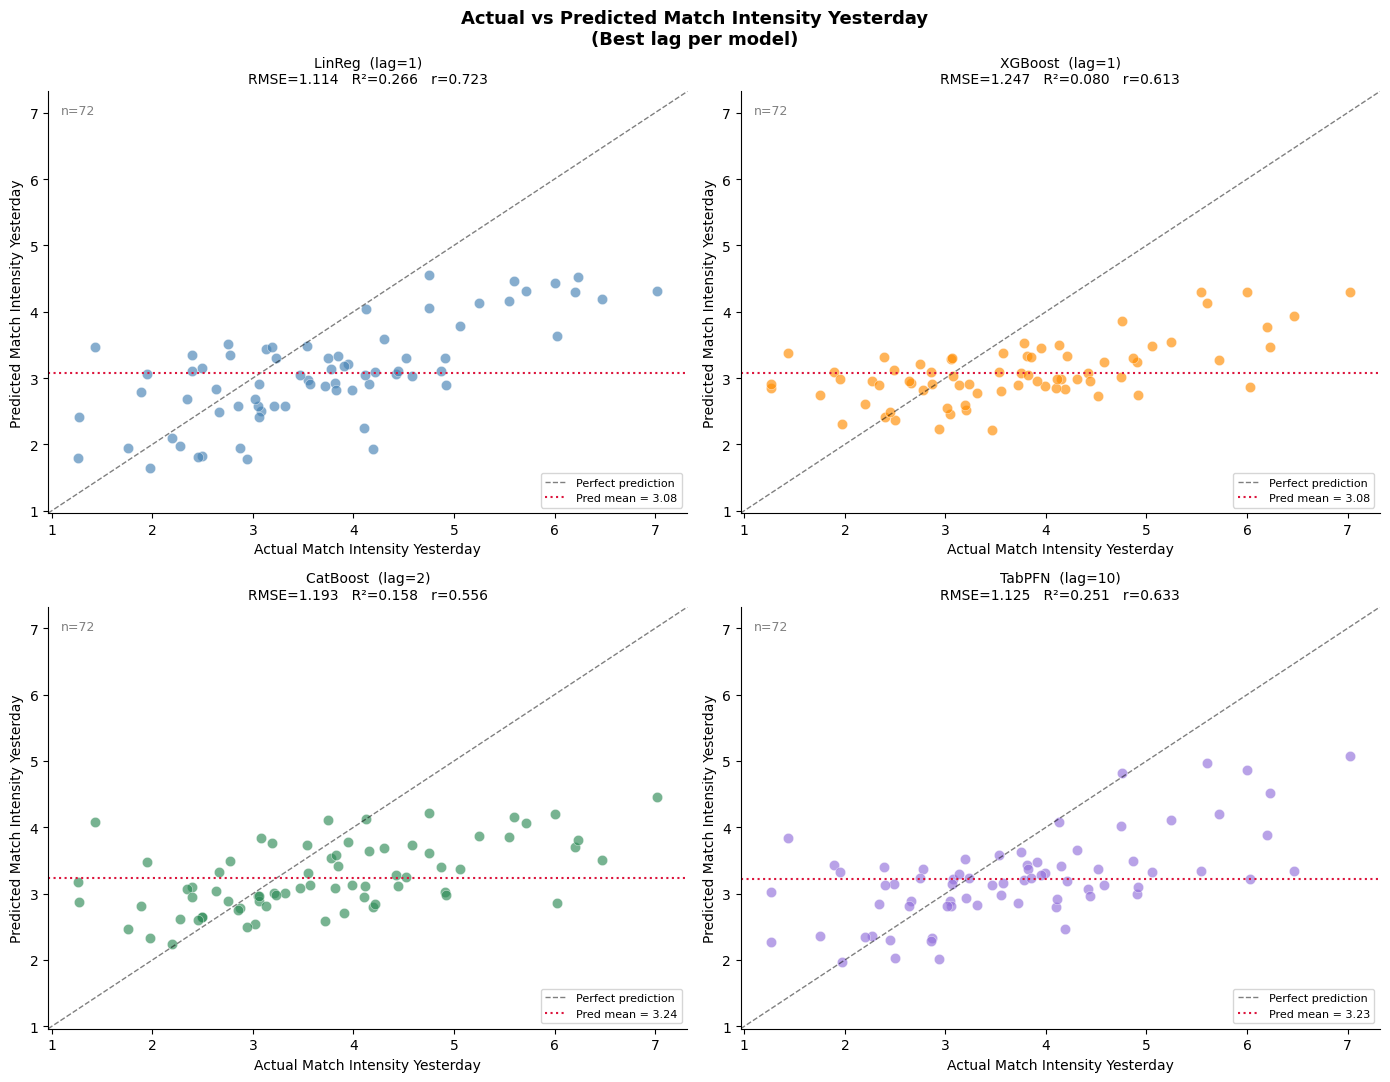


Observation: predictions cluster around the training mean.
The near-horizontal cloud is the hallmark of a near-zero-correlation predictor.


In [9]:
# ── 8.1 Actual vs Predicted ───────────────────────────────────────────────────
best_lags_all = {
    'LinReg':   min(linreg_results,  key=lambda l: linreg_results[l]['metrics']['rmse']),
    'XGBoost':  min(xgb_results,     key=lambda l: xgb_results[l]['metrics']['rmse']),
    'CatBoost': min(cat_results,     key=lambda l: cat_results[l]['metrics']['rmse']),
    'TabPFN':   min(tabpfn_results,  key=lambda l: tabpfn_results[l]['metrics']['rmse']),
}
all_res_dicts = {
    'LinReg':   linreg_results,
    'XGBoost':  xgb_results,
    'CatBoost': cat_results,
    'TabPFN':   tabpfn_results,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
fig.suptitle('Actual vs Predicted Match Intensity Yesterday\n(Best lag per model)',
             fontsize=13, fontweight='bold')

for ax, model_name in zip(axes, ['LinReg', 'XGBoost', 'CatBoost', 'TabPFN']):
    best_lag = best_lags_all[model_name]
    r = all_res_dicts[model_name][best_lag]
    y_true = r['y_test_true']
    y_pred = r['y_test_pred']
    m = r['metrics']
    color = MODEL_PALETTE[model_name]

    ax.scatter(y_true, y_pred, alpha=0.65, s=55, color=color,
               edgecolors='white', linewidths=0.4)

    lo = min(y_true.min(), y_pred.min()) - 0.3
    hi = max(y_true.max(), y_pred.max()) + 0.3
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5, label='Perfect prediction')
    ax.axhline(y_pred.mean(), color='crimson', linestyle=':', lw=1.5,
               label=f'Pred mean = {y_pred.mean():.2f}')

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual Match Intensity Yesterday')
    ax.set_ylabel('Predicted Match Intensity Yesterday')
    ax.set_title(
        f'{model_name}  (lag={best_lag})\n'
        f'RMSE={m["rmse"]:.3f}   R²={m["r2"]:.3f}   r={m["pearson_r"]:.3f}',
        fontsize=10)
    ax.legend(fontsize=8)
    ax.text(0.02, 0.97, f'n={len(y_true)}', transform=ax.transAxes,
            va='top', fontsize=9, color='grey')

plt.tight_layout()
plt.show()

print('\nObservation: predictions cluster around the training mean.')
print('The near-horizontal cloud is the hallmark of a near-zero-correlation predictor.')


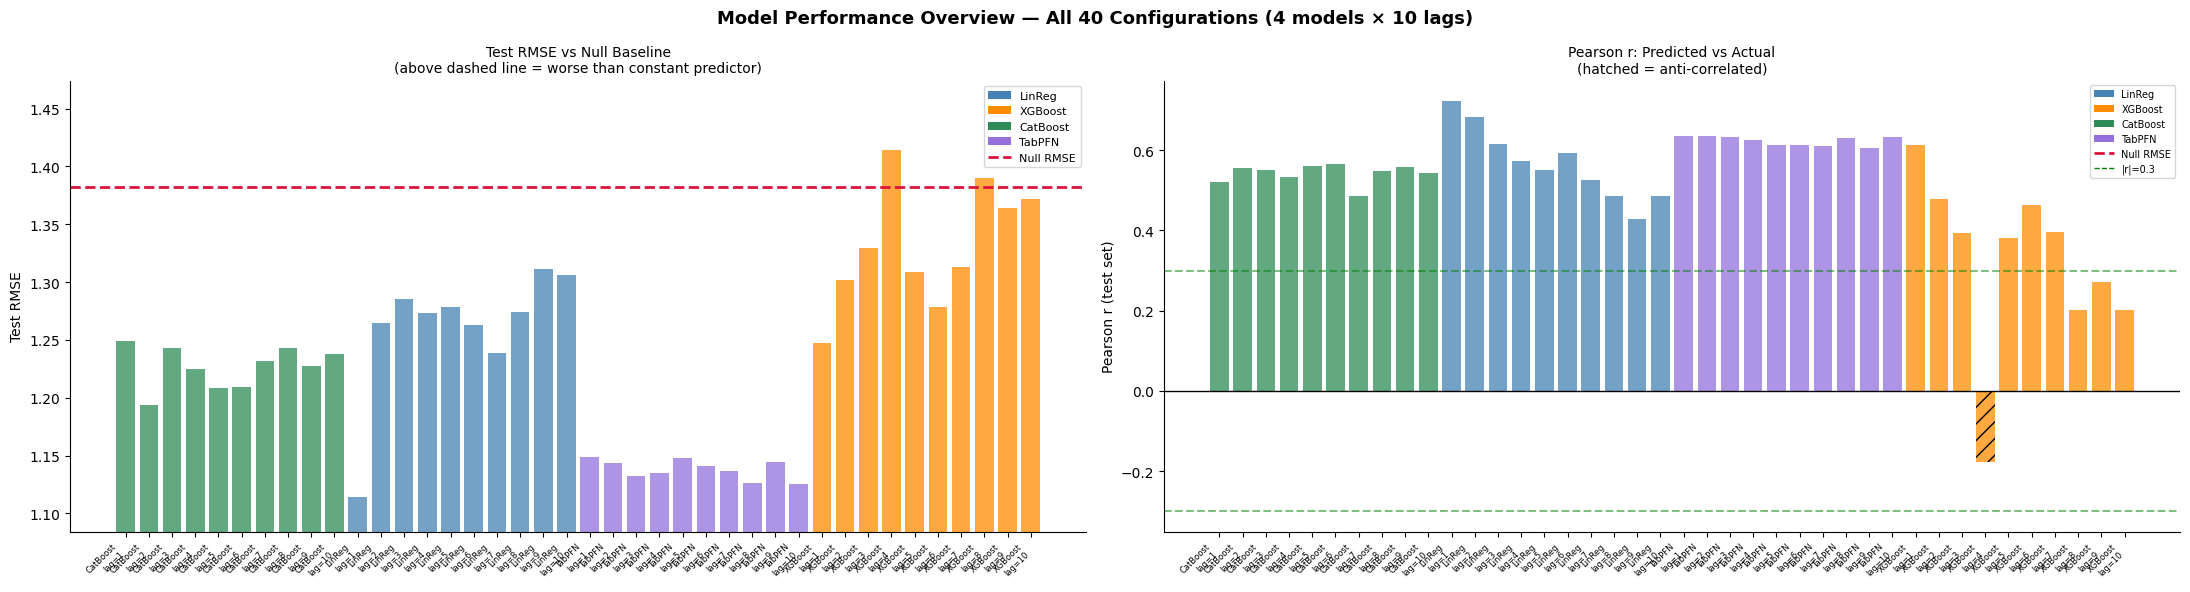


=== Best Configuration per Model (lowest Test RMSE) ===
   Model  Best Lag  Test RMSE  Null RMSE  RMSE − Null     R²  Pearson r
  LinReg         1     1.1142      1.382      -0.2678 0.2658     0.7228
 XGBoost         1     1.2475      1.382      -0.1345 0.0797     0.6131
CatBoost         2     1.1935      1.382      -0.1885 0.1576     0.5559
  TabPFN        10     1.1253      1.382      -0.2566 0.2511     0.6333


In [10]:
# ── 8.2 RMSE vs Null Baseline + Pearson r ────────────────────────────────────
rows_viz = []
for model_name, res_dict in all_res_dicts.items():
    for lag, r in res_dict.items():
        m = r['metrics']
        rows_viz.append({
            'Model': model_name,
            'Lag': lag,
            'Label': f'{model_name}\nlag={lag}',
            'RMSE': m['rmse'],
            'Null RMSE': m['null_rmse'],
            'Pearson r': m['pearson_r'],
            'R²': m['r2'],
        })

viz_df = pd.DataFrame(rows_viz).sort_values(['Model', 'Lag']).reset_index(drop=True)
null_val = viz_df['Null RMSE'].iloc[0]
x = np.arange(len(viz_df))
bar_cols_viz = [MODEL_PALETTE[m] for m in viz_df['Model']]

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
fig.suptitle('Model Performance Overview — All 40 Configurations (4 models × 10 lags)',
             fontsize=13, fontweight='bold')

# Left: RMSE
ax = axes[0]
ax.bar(x, viz_df['RMSE'], color=bar_cols_viz, alpha=0.75)
ax.axhline(null_val, color='crimson', linestyle='--', lw=2,
           label=f'Null RMSE = {null_val:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(viz_df['Label'], rotation=45, ha='right', fontsize=6)
ax.set_ylabel('Test RMSE')
ax.set_title('Test RMSE vs Null Baseline\n(above dashed line = worse than constant predictor)', fontsize=10)
legend_els_viz = [Patch(facecolor=c, label=m) for m, c in MODEL_PALETTE.items()]
legend_els_viz.append(plt.Line2D([0], [0], color='crimson', linestyle='--', lw=2, label='Null RMSE'))
ax.legend(handles=legend_els_viz, fontsize=8)
ax.set_ylim(viz_df['RMSE'].min() - 0.03, viz_df['RMSE'].max() + 0.06)

# Right: Pearson r
ax = axes[1]
r_vals = viz_df['Pearson r'].values
bars_r = ax.bar(x, r_vals, color=bar_cols_viz, alpha=0.75)
for bar, v in zip(bars_r, r_vals):
    if v < 0:
        bar.set_hatch('//')
ax.axhline(0, color='black', lw=1)
ax.axhline(0.3,  color='green', linestyle='--', alpha=0.5, label='|r|=0.3')
ax.axhline(-0.3, color='green', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(viz_df['Label'], rotation=45, ha='right', fontsize=6)
ax.set_ylabel('Pearson r (test set)')
ax.set_title('Pearson r: Predicted vs Actual\n(hatched = anti-correlated)', fontsize=10)
ax.legend(handles=legend_els_viz + [plt.Line2D([0],[0], color='green', linestyle='--', lw=1, label='|r|=0.3')],
          fontsize=7)

plt.tight_layout()
plt.show()

print('\n=== Best Configuration per Model (lowest Test RMSE) ===')
best_rows_final = []
for model_name, res_dict in all_res_dicts.items():
    bl = min(res_dict, key=lambda l: res_dict[l]['metrics']['rmse'])
    m = res_dict[bl]['metrics']
    best_rows_final.append({
        'Model': model_name, 'Best Lag': bl,
        'Test RMSE': round(m['rmse'], 4), 'Null RMSE': round(m['null_rmse'], 4),
        'RMSE − Null': round(m['rmse'] - m['null_rmse'], 4),
        'R²': round(m['r2'], 4), 'Pearson r': round(m['pearson_r'], 4),
    })
print(pd.DataFrame(best_rows_final).to_string(index=False))


### 2.4 Feature importance analysis (TabPFN)

Group-level permutation importance, leave-one-out ablation, greedy forward selection, Player ID contribution, feature×lag heatmap.


In [11]:
# -- 7.1 Setup: load data with best TabPFN lag, fit model, compute permutation importance --
import re
from tqdm import tqdm
from src.data.data_loader import ReadinessDataLoader
from tabpfn import TabPFNRegressor

# -- Pick best TabPFN lag (lowest test RMSE from section 4) -------------------
best_tfn_lag = min(tabpfn_results, key=lambda l: tabpfn_results[l]['metrics']['rmse'])
print(f'Best TabPFN lag: {best_tfn_lag}  '
      f'(RMSE = {tabpfn_results[best_tfn_lag]["metrics"]["rmse"]:.4f})')

# -- Reload data at the best lag -----------------------------------------------
loader6 = ReadinessDataLoader()
data6 = loader6.create_dataset(
    target_variable='Match Intensity Yesterday',
    predictory_columns=COVARIATES,
    lag=best_tfn_lag,
    target_horizon=1,
    test_size=0.2,
    val_size=0.1,
    categorical_encoding='one-hot',
    standardize=False,
    missing_numeric='mean',
    missing_categorical='mode',
)

feat_names_raw = list(data6['feature_names'])
X_train_raw = data6['X_train'].copy()
X_test_raw  = data6['X_test'].copy()
y_train_6 = data6['y_train'].values.astype(float)
y_test_6  = data6['y_test'].values.astype(float)

# -- Drop redundant Player ID lag copies --------------------------------------
pid_lag_cols = [
    c for c in feat_names_raw
    if re.match(r'^Player ID', c) and re.search(r'_t-\d+$', c)
]
keep_cols = [c for c in feat_names_raw if c not in pid_lag_cols]

X_train_6  = X_train_raw[keep_cols].values.astype(float)
X_test_6   = X_test_raw[keep_cols].values.astype(float)
feat_names_6 = keep_cols

print(f'\nFeatures before dropping Player ID lag copies: {len(feat_names_raw)}')
print(f'Player ID lag copies dropped:                  {len(pid_lag_cols)}')
print(f'Features after pruning:                        {len(feat_names_6)}')
print(f'\nData shapes:  train = {X_train_6.shape}  |  test = {X_test_6.shape}')

# -- Fit TabPFN on GPU --------------------------------------------------------
print('\nFitting TabPFN on training data (GPU)...')
tfn_6 = TabPFNRegressor(n_estimators=4, device='cuda')
tfn_6.fit(X_train_6, y_train_6)

y_pred_bl_6 = tfn_6.predict(X_test_6)
bl_rmse_6   = float(np.sqrt(np.mean((y_test_6 - y_pred_bl_6) ** 2)))
null_rmse_6 = float(np.sqrt(np.mean((y_test_6 - y_train_6.mean()) ** 2)))
print(f'Baseline RMSE (all features):   {bl_rmse_6:.4f}')
print(f'Null RMSE (predict train mean): {null_rmse_6:.4f}')

# -- Build covariate groups for GROUP-LEVEL permutation importance -------------
# Instead of shuffling each column individually (100+ features x N repeats =
# thousands of predictions), we shuffle all columns belonging to the same
# covariate group simultaneously. This is both:
#   (a) faster: ~8 groups x 10 repeats = 80 predictions (vs 2500+)
#   (b) more correct: shuffling one lag copy but not another underestimates
#       the true importance because the other copies still carry the signal.

def base_name_6(feat: str) -> str:
    """Strip lag suffix (_t-1, _t-2 ...) -> base covariate name."""
    return re.sub(r'_t-\d+$', '', feat)

def base_group_6(feat: str) -> str:
    """Group Player ID one-hot columns together; strip lag suffix from others."""
    if re.match(r'^Player ID', feat):
        return 'Player ID'
    return re.sub(r'_t-\d+$', '', feat)

# Map each group name -> list of column indices
group_indices = {}
for j, feat in enumerate(feat_names_6):
    g = base_group_6(feat)
    group_indices.setdefault(g, []).append(j)

print(f'\nCovariate groups ({len(group_indices)}):')
for g, idxs in group_indices.items():
    print(f'  {g:52s}  {len(idxs):3d} columns')

# -- Group-level permutation importance (N_REPEATS shuffles per group) ---------
N_REPEATS = 10
rng6 = np.random.default_rng(seed=42)
n_preds = len(group_indices) * N_REPEATS
print(f'\nComputing group-level permutation importance '
      f'({N_REPEATS} repeats x {len(group_indices)} groups = {n_preds} predictions)...')

grouped_perm_6 = {}   # {group_name: [delta_rmse per repeat]}

for group_name, col_idxs in tqdm(group_indices.items(), desc="Permutation importance"):
    deltas = []
    for _ in range(N_REPEATS):
        X_perm = X_test_6.copy()
        perm_order = rng6.permutation(X_perm.shape[0])
        for j in col_idxs:
            X_perm[:, j] = X_perm[perm_order, j]
        y_pp = tfn_6.predict(X_perm)
        deltas.append(float(np.sqrt(np.mean((y_test_6 - y_pp) ** 2))) - bl_rmse_6)
    grouped_perm_6[group_name] = deltas

print('Done.')

# -- Also store per-feature results for downstream cells -----------------------
perm_deltas_6 = {}
for group_name, col_idxs in group_indices.items():
    for j in col_idxs:
        perm_deltas_6[feat_names_6[j]] = grouped_perm_6[group_name]

perm_mean_6 = pd.Series(
    {bn: np.mean(v) for bn, v in grouped_perm_6.items()}
).sort_values(ascending=False)

perm_sem_6 = pd.Series(
    {bn: np.std(v) / np.sqrt(len(v)) for bn, v in grouped_perm_6.items()}
).loc[perm_mean_6.index]

# -- Text summary --------------------------------------------------------------
print(f'\n=== Grouped Permutation Importance (baseline RMSE = {bl_rmse_6:.4f}) ===')
print('Positive delta-RMSE -> shuffling hurts performance -> feature is useful')
print('Negative delta-RMSE -> shuffling helps performance -> feature adds noise')
print()
for bn in perm_mean_6.index:
    mv  = perm_mean_6[bn]
    sem = perm_sem_6[bn]
    bar = '#' * max(0, int(abs(mv) / 0.001))
    print(f'  {bn:52s}  {mv:+.4f} +/- {sem:.4f}  {bar}')



Best TabPFN lag: 10  (RMSE = 1.1253)

Features before dropping Player ID lag copies: 385
Player ID lag copies dropped:                  0
Features after pruning:                        385

Data shapes:  train = (248, 385)  |  test = (72, 385)

Fitting TabPFN on training data (GPU)...
Baseline RMSE (all features):   1.1063
Null RMSE (predict train mean): 1.3820

Covariate groups (13):
  Physical State                                         11 columns
  Mental State                                           11 columns
  Training Intensity Yesterday                           11 columns
  Total Distance (ACWR) Yesterday                        11 columns
  High Speed Distance (ACWR) Yesterday                   11 columns
  Any ACWR Danger                                        11 columns
  Total Distance % Yesterday                             11 columns
  High Speed Distance % Yesterday                        11 columns
  Perceived Exertion Yesterday                           11 columns


Permutation importance: 100%|██████████| 13/13 [01:59<00:00,  9.19s/it]

Done.

=== Grouped Permutation Importance (baseline RMSE = 1.1063) ===
Positive delta-RMSE -> shuffling hurts performance -> feature is useful
Negative delta-RMSE -> shuffling helps performance -> feature adds noise

  Player ID                                             +0.3859 +/- 0.0233  #################################################################################################################################################################################################################################################################################################################################################################################################
  High Speed Distance (ACWR) Yesterday                  +0.0107 +/- 0.0015  ##########
  Total Minutes Yesterday                               +0.0046 +/- 0.0015  ####
  Total Distance % Yesterday                            +0.0026 +/- 0.0004  ##
  Any ACWR Danger                                       +0.0019 +/- 0.0002

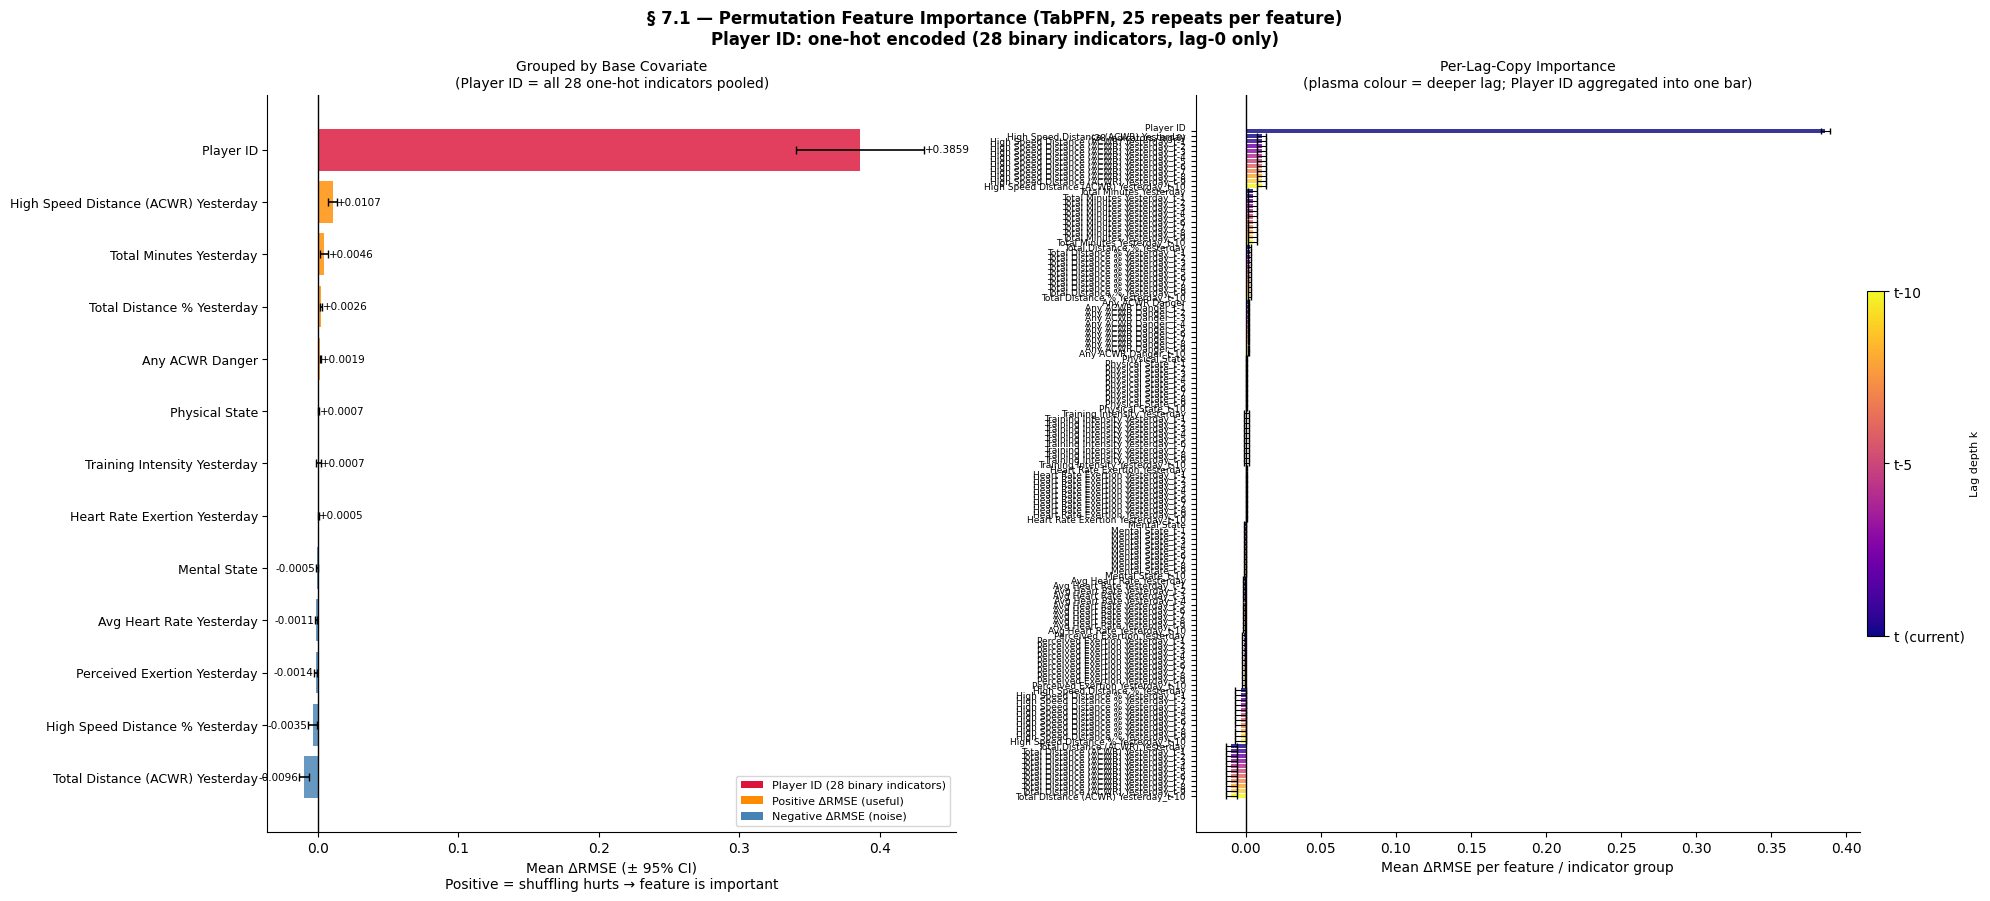

In [12]:
# ── § 7.1 Visualization: Grouped + Per-Lag-Copy Permutation Importance ────────
fig, axes = plt.subplots(1, 2, figsize=(20, max(6, len(perm_mean_6) * 0.55 + 2)))
fig.suptitle('§ 7.1 — Permutation Feature Importance (TabPFN, 25 repeats per feature)\n'
             'Player ID: one-hot encoded (28 binary indicators, lag-0 only)',
             fontsize=12, fontweight='bold')

# ── Left panel: Grouped bar chart with 95% CI ─────────────────────────────────
ax = axes[0]
means_g = perm_mean_6.values
ci95_g  = 1.96 * perm_sem_6.values
y_pos_g = np.arange(len(perm_mean_6))

bar_cols_g = ['crimson'    if 'Player ID' in bn
              else ('darkorange' if mv >= 0 else 'steelblue')
              for bn, mv in perm_mean_6.items()]

ax.barh(y_pos_g, means_g[::-1], xerr=ci95_g[::-1],
        color=bar_cols_g[::-1], alpha=0.82,
        error_kw=dict(ecolor='black', capsize=3, lw=1.2))
ax.set_yticks(y_pos_g)
ax.set_yticklabels(list(perm_mean_6.index[::-1]), fontsize=9)
ax.axvline(0, color='black', lw=1)

for i, (mv, ci) in enumerate(zip(means_g[::-1], ci95_g[::-1])):
    offset = ci + 0.0003
    ax.text(mv + offset if mv >= 0 else mv - offset, i,
            f'{mv:+.4f}', va='center', ha='left' if mv >= 0 else 'right', fontsize=7.5)

ax.set_xlabel('Mean ΔRMSE (± 95% CI)\n'
              'Positive = shuffling hurts → feature is important')
ax.set_title('Grouped by Base Covariate\n'
             '(Player ID = all 28 one-hot indicators pooled)', fontsize=10)
legend_els_g = [
    Patch(facecolor='crimson',    label='Player ID (28 binary indicators)'),
    Patch(facecolor='darkorange', label='Positive ΔRMSE (useful)'),
    Patch(facecolor='steelblue',  label='Negative ΔRMSE (noise)'),
]
ax.legend(handles=legend_els_g, fontsize=8, loc='lower right')

# ── Right panel: Per-lag-copy, coloured by lag depth ──────────────────────────
# For non-Player-ID features: show individual lag copies (_t-0, _t-1, ...) coloured by depth.
# For Player ID: aggregate all 28 one-hot indicators into one bar at lag-0.
ax = axes[1]

# Identify lag levels from feature names (after dropping Player ID lag copies)
lag_levels_present = sorted({
    int(re.search(r'_t-(\d+)$', f).group(1))
    for f in feat_names_6 if re.search(r'_t-\d+$', f)
})
no_lag_feats = [f for f in feat_names_6 if not re.search(r'_t-\d+$', f)
                and not re.match(r'^Player ID', f)]   # non-lag, non-PID features

# Build ordered list: for each base name (in importance order) → lag-0, _t-1, _t-2, ...
# For 'Player ID', insert a single aggregated entry instead of 28 individual columns.
feat_order_perlag  = []   # display names
feat_mean_perlag   = []   # mean ΔRMSE
feat_ci95_perlag   = []   # 95% CI
feat_lagdepth      = []   # lag depth (for colour)

for bn in perm_mean_6.index:
    if bn == 'Player ID':
        # Aggregate all 28 indicator columns into a single entry
        pid_feats = [f for f in feat_names_6 if re.match(r'^Player ID', f)]
        all_deltas_pid = []
        for pf in pid_feats:
            all_deltas_pid.extend(perm_deltas_6[pf])
        feat_order_perlag.append('Player ID\n(28 indicators, lag-0)')
        feat_mean_perlag.append(np.mean(all_deltas_pid))
        feat_ci95_perlag.append(1.96 * np.std(all_deltas_pid) / np.sqrt(len(all_deltas_pid)))
        feat_lagdepth.append(0)   # lag-0
    else:
        # Current-row (no lag suffix) copy
        for f in no_lag_feats:
            if base_name_6(f) == bn:
                feat_order_perlag.append(f)
                feat_mean_perlag.append(np.mean(perm_deltas_6[f]))
                feat_ci95_perlag.append(1.96 * np.std(perm_deltas_6[f]) / np.sqrt(N_REPEATS))
                feat_lagdepth.append(0)
        # Lag-k copies
        for k in lag_levels_present:
            for f in feat_names_6:
                if base_name_6(f) == bn and f.endswith(f'_t-{k}'):
                    feat_order_perlag.append(f)
                    feat_mean_perlag.append(np.mean(perm_deltas_6[f]))
                    feat_ci95_perlag.append(1.96 * np.std(perm_deltas_6[f]) / np.sqrt(N_REPEATS))
                    feat_lagdepth.append(k)

cmap_lag  = plt.cm.plasma
max_lag_k = max(lag_levels_present) if lag_levels_present else 1

def lag_color_depth(depth):
    return cmap_lag(depth / max_lag_k) if max_lag_k > 0 else cmap_lag(0.05)

y_pos_f    = np.arange(len(feat_order_perlag))
bar_cols_f = [lag_color_depth(d) for d in feat_lagdepth]

ax.barh(y_pos_f, feat_mean_perlag[::-1], xerr=feat_ci95_perlag[::-1],
        color=bar_cols_f[::-1], alpha=0.82,
        error_kw=dict(ecolor='black', capsize=2, lw=0.8))
ax.set_yticks(y_pos_f)
ax.set_yticklabels(feat_order_perlag[::-1], fontsize=6.5)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Mean ΔRMSE per feature / indicator group')
ax.set_title('Per-Lag-Copy Importance\n'
             '(plasma colour = deeper lag; Player ID aggregated into one bar)', fontsize=10)

sm_lag = plt.cm.ScalarMappable(cmap=cmap_lag, norm=plt.Normalize(0, max_lag_k))
sm_lag.set_array([])
cbar = plt.colorbar(sm_lag, ax=ax, orientation='vertical', fraction=0.025, pad=0.01)
cbar.set_label('Lag depth k', fontsize=8)
cbar.set_ticks([0, max_lag_k // 2, max_lag_k])
cbar.set_ticklabels(['t (current)', f't-{max_lag_k // 2}', f't-{max_lag_k}'])

plt.tight_layout()
plt.show()



=== § 7.2 — Leave-One-Out Ablation (TabPFN, lag=10) ===

Baseline RMSE (all 13 covariates):  1.1063
Null RMSE (predict train mean):            1.3820

Dropping one base covariate at a time ...



LOO ablation:   8%|▊         | 1/13 [00:03<00:37,  3.16s/it]

  drop [Physical State                               ]  RMSE=1.1262  Δ=+0.0199  [USEFUL]


LOO ablation:  15%|█▌        | 2/13 [00:06<00:34,  3.10s/it]

  drop [Mental State                                 ]  RMSE=1.1241  Δ=+0.0178  [USEFUL]


...

  drop [Avg Heart Rate Yesterday                     ]  RMSE=1.1262  Δ=+0.0199  [USEFUL]


LOO ablation:  92%|█████████▏| 12/13 [00:37<00:03,  3.08s/it]

  drop [Heart Rate Exertion Yesterday                ]  RMSE=1.1224  Δ=+0.0161  [USEFUL]


LOO ablation: 100%|██████████| 13/13 [00:40<00:00,  3.12s/it]

  drop [Player ID                                    ]  RMSE=1.3743  Δ=+0.2680  [USEFUL]


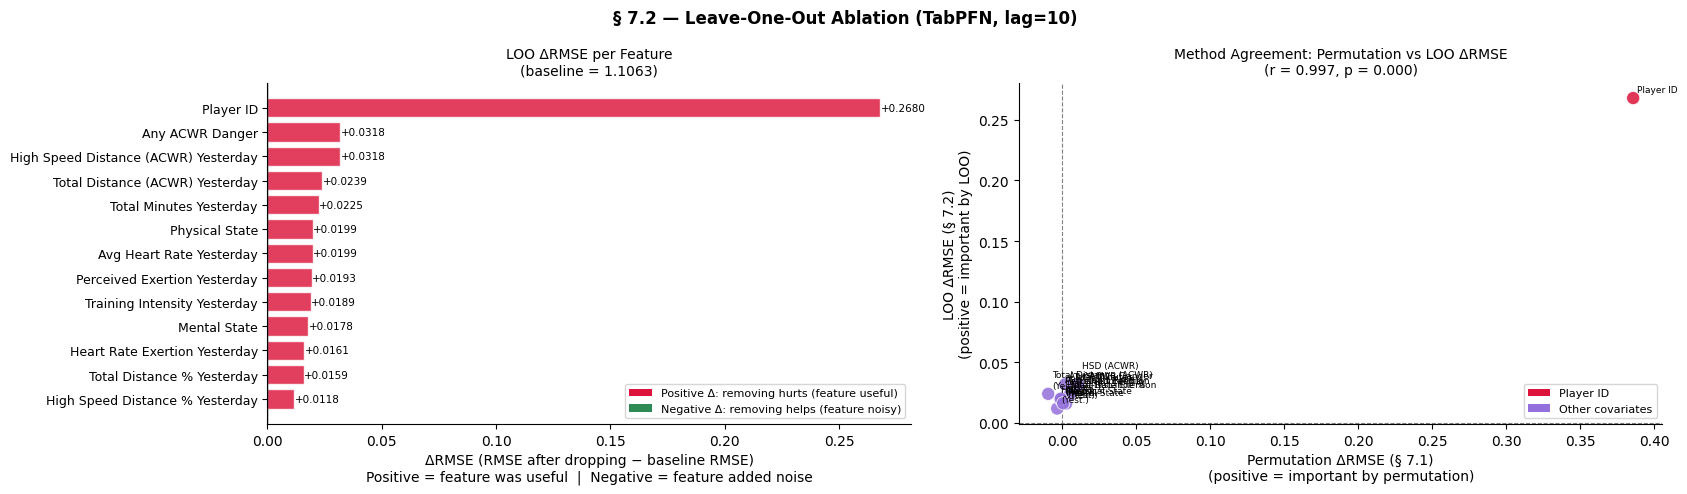


=== LOO Summary Table ===
                                        rmse   delta
Player ID                             1.3743  0.2680
Any ACWR Danger                       1.1381  0.0318
High Speed Distance (ACWR) Yesterday  1.1381  0.0318
Total Distance (ACWR) Yesterday       1.1302  0.0239
Total Minutes Yesterday               1.1288  0.0225
Physical State                        1.1262  0.0199
Avg Heart Rate Yesterday              1.1262  0.0199
Perceived Exertion Yesterday          1.1256  0.0193
Training Intensity Yesterday          1.1252  0.0189
Mental State                          1.1241  0.0178
Heart Rate Exertion Yesterday         1.1224  0.0161
Total Distance % Yesterday            1.1222  0.0159
High Speed Distance % Yesterday       1.1181  0.0118


In [13]:
from tqdm import tqdm
# ── § 7.2 Leave-One-Out Ablation (TabPFN) ────────────────────────────────────
# Drop the entire group of lag copies for one base covariate at a time.
# Positive ΔRMSE = feature group was useful; negative = feature group added noise.
print(f'=== § 7.2 — Leave-One-Out Ablation (TabPFN, lag={best_tfn_lag}) ===\n')
print(f'Baseline RMSE (all {len(COVARIATES)} covariates):  {bl_rmse_6:.4f}')
print(f'Null RMSE (predict train mean):            {null_rmse_6:.4f}')
print(f'\nDropping one base covariate at a time ...\n')

loo_tfn = {}
for drop_cov in tqdm(COVARIATES, desc="LOO ablation"):
    remaining_loo = [c for c in COVARIATES if c != drop_cov]
    r_loo = run_experiment(
        covariates=remaining_loo,
        lag=best_tfn_lag,
        model_type='tabpfn',
        verbose=False,
        **GPU_OVERRIDES.get('tabpfn', {}),
    )
    loo_rmse  = r_loo['metrics']['rmse']
    delta_loo = loo_rmse - bl_rmse_6
    loo_tfn[drop_cov] = {'rmse': loo_rmse, 'delta': delta_loo}
    sign = '+' if delta_loo >= 0 else ''
    verdict = 'USEFUL'  if delta_loo > 0.001 else ('NOISE' if delta_loo < -0.001 else 'neutral')
    print(f'  drop [{drop_cov:45s}]  RMSE={loo_rmse:.4f}  Δ={sign}{delta_loo:.4f}  [{verdict}]')

loo_df = pd.DataFrame(loo_tfn).T.sort_values('delta', ascending=False)
loo_df['delta'] = loo_df['delta'].round(4)
loo_df['rmse']  = loo_df['rmse'].round(4)

# ── Figure: LOO ΔRMSE bar + method-agreement scatter ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle(f'§ 7.2 — Leave-One-Out Ablation (TabPFN, lag={best_tfn_lag})',
             fontsize=12, fontweight='bold')

# Panel A: LOO ΔRMSE bar chart
ax = axes[0]
colors_loo2 = ['crimson' if v > 0 else 'seagreen' for v in loo_df['delta'].values]
ax.barh(range(len(loo_df)), loo_df['delta'].values[::-1],
        color=colors_loo2[::-1], alpha=0.82, edgecolor='white')
ax.set_yticks(range(len(loo_df)))
ax.set_yticklabels(list(loo_df.index[::-1]), fontsize=9)
ax.axvline(0, color='black', lw=1)

# Annotate values
for i, v in enumerate(loo_df['delta'].values[::-1]):
    offset = 0.0002
    ax.text(v + (offset if v >= 0 else -offset), i, f'{v:+.4f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=7.5)

ax.set_xlabel('ΔRMSE (RMSE after dropping − baseline RMSE)\n'
              'Positive = feature was useful  |  Negative = feature added noise')
ax.set_title(f'LOO ΔRMSE per Feature\n(baseline = {bl_rmse_6:.4f})', fontsize=10)
legend_loo2 = [
    Patch(facecolor='crimson',  label='Positive Δ: removing hurts (feature useful)'),
    Patch(facecolor='seagreen', label='Negative Δ: removing helps (feature noisy)'),
]
ax.legend(handles=legend_loo2, fontsize=8)

# Panel B: Method-agreement scatter (Permutation ΔRMSE vs LOO ΔRMSE)
ax = axes[1]
common_c = [c for c in COVARIATES if c in loo_df.index and c in perm_mean_6.index]
x_perm_sc = np.array([perm_mean_6[c] for c in common_c])
y_loo_sc  = np.array([loo_df.loc[c, 'delta'] for c in common_c])

scatter_colors = ['crimson' if 'Player ID' in c else 'mediumpurple' for c in common_c]
ax.scatter(x_perm_sc, y_loo_sc, s=90, c=scatter_colors, alpha=0.85,
           edgecolors='white', linewidths=0.6, zorder=3)

for i, cov in enumerate(common_c):
    short_lbl = cov.replace(' Yesterday', '\n(Yest.)').replace('High Speed Distance', 'HSD')
    ax.annotate(short_lbl, (x_perm_sc[i], y_loo_sc[i]),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.axvline(0, color='grey', lw=0.8, linestyle='--')

if len(common_c) > 2:
    from scipy import stats as scipy_stats
    r_agree, p_agree = scipy_stats.pearsonr(x_perm_sc, y_loo_sc)
    ax.set_title(f'Method Agreement: Permutation vs LOO ΔRMSE\n'
                 f'(r = {r_agree:.3f}, p = {p_agree:.3f})', fontsize=10)
else:
    ax.set_title('Method Agreement: Permutation vs LOO ΔRMSE', fontsize=10)

ax.set_xlabel('Permutation ΔRMSE (§ 7.1)\n(positive = important by permutation)')
ax.set_ylabel('LOO ΔRMSE (§ 7.2)\n(positive = important by LOO)')

legend_sc = [
    Patch(facecolor='crimson',     label='Player ID'),
    Patch(facecolor='mediumpurple',label='Other covariates'),
]
ax.legend(handles=legend_sc, fontsize=8)

plt.tight_layout()
plt.show()

print('\n=== LOO Summary Table ===')
print(loo_df.to_string())



=== § 7.3 — Greedy Forward Feature Selection (TabPFN, lag=10) ===

Null RMSE (predict training mean):  1.3820
Full-set baseline RMSE:             1.1063

Running greedy forward selection (13 steps)...



  Step  1: Added [Player ID                                    ]  RMSE=1.1185  ΔNull=+0.2635  Δprev=+0.2635


  Step  2: Added [High Speed Distance (ACWR) Yesterday         ]  RMSE=1.0946  ΔNull=+0.2873  Δprev=+0.0239


  Step  3: Added [Any ACWR Danger                              ]  RMSE=1.0846  ΔNull=+0.2973  Δprev=+0.0100


  Step  4: Added [Heart Rate Exertion Yesterday                ]  RMSE=1.0934  ΔNull=+0.2885  Δprev=-0.0088


...

  Step  9: Added [Physical State                               ]  RMSE=1.1006  ΔNull=+0.2813  Δprev=-0.0024


  Step 10: Added [Perceived Exertion Yesterday                 ]  RMSE=1.1072  ΔNull=+0.2748  Δprev=-0.0065


  Step 11: Added [Training Intensity Yesterday                 ]  RMSE=1.1085  ΔNull=+0.2735  Δprev=-0.0013


  Step 12: Added [High Speed Distance % Yesterday              ]  RMSE=1.1359  ΔNull=+0.2461  Δprev=-0.0274


  Step 13: Added [Total Distance % Yesterday                   ]  RMSE=1.1235  ΔNull=+0.2585  Δprev=+0.0124


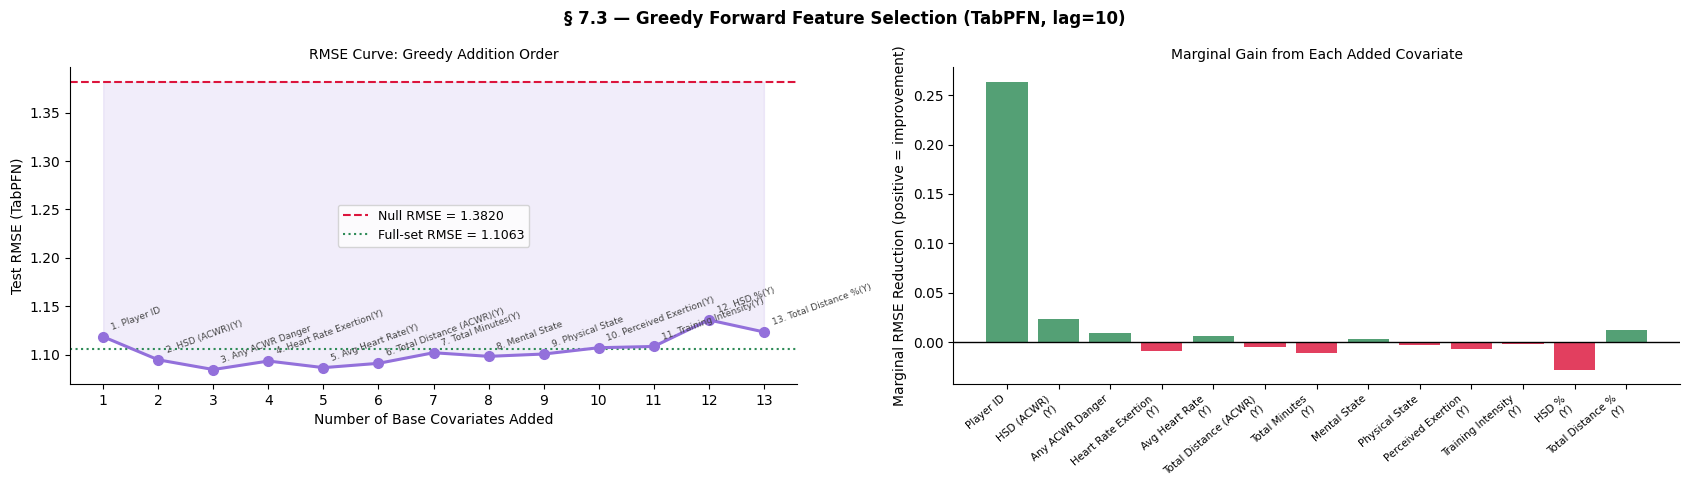


=== Greedy Addition Order (marginal gain ranking) ===
   1. Player ID                                             RMSE=1.1185  Marginal=+0.2635  Cumulative gain=+0.2635
   2. High Speed Distance (ACWR) Yesterday                  RMSE=1.0946  Marginal=+0.0239  Cumulative gain=+0.2873
   3. Any ACWR Danger                                       RMSE=1.0846  Marginal=+0.0100  Cumulative gain=+0.2973
   4. Heart Rate Exertion Yesterday                         RMSE=1.0934  Marginal=-0.0088  Cumulative gain=+0.2885
   5. Avg Heart Rate Yesterday                              RMSE=1.0866  Marginal=+0.0068  Cumulative gain=+0.2954
   6. Total Distance (ACWR) Yesterday                       RMSE=1.0910  Marginal=-0.0045  Cumulative gain=+0.2909
   7. Total Minutes Yesterday                               RMSE=1.1020  Marginal=-0.0109  Cumulative gain=+0.2800
   8. Mental State                                          RMSE=1.0982  Marginal=+0.0037  Cumulative gain=+0.2837
   9. Physical State     

In [14]:
from tqdm import tqdm
# ── § 7.3 Greedy Forward Feature Selection (TabPFN) ──────────────────────────
# Start empty; greedily add the base-covariate group that most reduces test RMSE.
print(f'=== § 7.3 — Greedy Forward Feature Selection (TabPFN, lag={best_tfn_lag}) ===\n')

null_rmse_greedy = float(np.sqrt(np.mean((y_test_6 - y_train_6.mean()) ** 2)))
print(f'Null RMSE (predict training mean):  {null_rmse_greedy:.4f}')
print(f'Full-set baseline RMSE:             {bl_rmse_6:.4f}')
print(f'\nRunning greedy forward selection ({len(COVARIATES)} steps)...\n')

remaining_g = list(COVARIATES)
selected_g  = []
greedy_rmse_curve = []   # RMSE after adding each covariate
greedy_order      = []   # which covariate was added at each step

while remaining_g:
    best_cov_g   = None
    best_rmse_g  = np.inf

    for cov_cand in tqdm(remaining_g, desc=f"Step {len(selected_g)+1}", leave=False):
        candidate_set = selected_g + [cov_cand]
        r_cand = run_experiment(
            covariates=candidate_set,
            lag=best_tfn_lag,
            model_type='tabpfn',
            verbose=False,
            **GPU_OVERRIDES.get('tabpfn', {}),
        )
        if r_cand['metrics']['rmse'] < best_rmse_g:
            best_rmse_g = r_cand['metrics']['rmse']
            best_cov_g  = cov_cand

    selected_g.append(best_cov_g)
    remaining_g.remove(best_cov_g)
    greedy_rmse_curve.append(best_rmse_g)
    greedy_order.append(best_cov_g)

    delta_null = null_rmse_greedy - best_rmse_g
    delta_prev = (greedy_rmse_curve[-2] - best_rmse_g) if len(greedy_rmse_curve) > 1 else delta_null
    print(f'  Step {len(selected_g):2d}: Added [{best_cov_g:45s}]  '
          f'RMSE={best_rmse_g:.4f}  ΔNull={delta_null:+.4f}  Δprev={delta_prev:+.4f}')

# ── Plot greedy selection curve ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle(f'§ 7.3 — Greedy Forward Feature Selection (TabPFN, lag={best_tfn_lag})',
             fontsize=12, fontweight='bold')

# Panel A: RMSE curve
ax = axes[0]
steps_g = range(1, len(greedy_rmse_curve) + 1)
ax.plot(steps_g, greedy_rmse_curve, 'o-', color='mediumpurple', lw=2.2, ms=7, zorder=3)
ax.fill_between(steps_g, greedy_rmse_curve, null_rmse_greedy,
                alpha=0.12, color='mediumpurple', label='_nolegend_')
ax.axhline(null_rmse_greedy, color='crimson', linestyle='--', lw=1.5,
           label=f'Null RMSE = {null_rmse_greedy:.4f}')
ax.axhline(bl_rmse_6, color='seagreen', linestyle=':', lw=1.5,
           label=f'Full-set RMSE = {bl_rmse_6:.4f}')

# Annotate each step
for i, (s, rmse_v) in enumerate(zip(steps_g, greedy_rmse_curve)):
    short = greedy_order[i].replace(' Yesterday', '(Y)').replace('High Speed Distance', 'HSD')
    ax.annotate(f'{s}. {short}', (s, rmse_v),
                textcoords='offset points', xytext=(5, 5),
                fontsize=6.5, rotation=20, ha='left', color='#444')

ax.set_xlabel('Number of Base Covariates Added')
ax.set_ylabel('Test RMSE (TabPFN)')
ax.set_title('RMSE Curve: Greedy Addition Order', fontsize=10)
ax.set_xticks(list(steps_g))
ax.legend(fontsize=9)

# Panel B: Marginal gain per step
ax = axes[1]
marginal = np.diff([null_rmse_greedy] + list(greedy_rmse_curve)) * -1   # positive = improvement
colors_g = ['seagreen' if m > 0 else 'crimson' for m in marginal]
ax.bar(range(1, len(marginal) + 1), marginal, color=colors_g, alpha=0.82)
ax.set_xticks(range(1, len(marginal) + 1))
ax.set_xticklabels(
    [o.replace(' Yesterday', '\n(Y)').replace('High Speed Distance', 'HSD')
     for o in greedy_order],
    rotation=40, ha='right', fontsize=7.5)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Marginal RMSE Reduction (positive = improvement)')
ax.set_title('Marginal Gain from Each Added Covariate', fontsize=10)

plt.tight_layout()
plt.show()

# ── Ranked importance table ────────────────────────────────────────────────
print('\n=== Greedy Addition Order (marginal gain ranking) ===')
for i, (cov, rmse_v) in enumerate(zip(greedy_order, greedy_rmse_curve)):
    mg = marginal[i]
    cum_gain = null_rmse_greedy - rmse_v
    print(f'  {i+1:2d}. {cov:52s}  RMSE={rmse_v:.4f}  '
          f'Marginal={mg:+.4f}  Cumulative gain={cum_gain:+.4f}')



=== § 7.4 — Player ID Contribution Across All Lags (TabPFN) ===

Covariates without Player ID (12):  ['Physical State', 'Mental State', 'Training Intensity Yesterday', 'Total Distance (ACWR) Yesterday', 'High Speed Distance (ACWR) Yesterday', 'Any ACWR Danger', 'Total Distance % Yesterday', 'High Speed Distance % Yesterday', 'Perceived Exertion Yesterday', 'Total Minutes Yesterday', 'Avg Heart Rate Yesterday', 'Heart Rate Exertion Yesterday']

Running TabPFN (no Player ID) for all 10 lag configurations...



TabPFN no-PID:  10%|█         | 1/10 [00:01<00:17,  1.98s/it]

  lag= 1  with PID=1.1487  no PID=1.4138  Δ=+0.2651  ✓ helpful


TabPFN no-PID:  20%|██        | 2/10 [00:03<00:15,  1.97s/it]

  lag= 2  with PID=1.1439  no PID=1.3956  Δ=+0.2517  ✓ helpful


...

  lag= 8  with PID=1.1262  no PID=1.3956  Δ=+0.2694  ✓ helpful


TabPFN no-PID:  90%|█████████ | 9/10 [00:21<00:02,  2.61s/it]

  lag= 9  with PID=1.1440  no PID=1.3900  Δ=+0.2460  ✓ helpful


TabPFN no-PID: 100%|██████████| 10/10 [00:24<00:00,  2.43s/it]

  lag=10  with PID=1.1253  no PID=1.3743  Δ=+0.2490  ✓ helpful


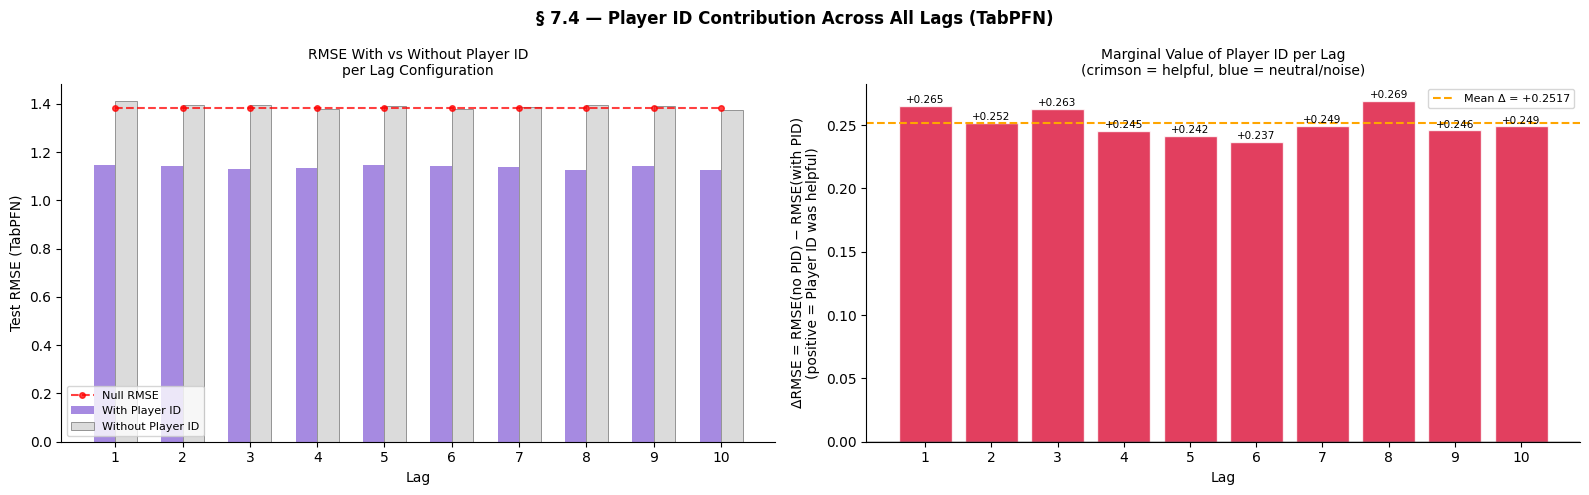


=== Player ID Contribution Summary ===
Mean ΔRMSE from adding Player ID:    +0.2517
Max  ΔRMSE (most helpful lag):       lag=8  Δ=+0.2694
Best lag with Player ID:             lag=10  RMSE=1.1253
Best lag without Player ID:          lag=10  RMSE=1.3743
Lags where Player ID helped:         10/10


In [15]:
from tqdm import tqdm
# ── § 7.4 Player ID Contribution Across All Lags (TabPFN) ────────────────────
# For each lag 1–10, compare TabPFN RMSE with vs without Player ID.
# Uses tabpfn_results (with Player ID, all lags) already computed in § 4.
print('=== § 7.4 — Player ID Contribution Across All Lags (TabPFN) ===\n')

covs_no_pid = [c for c in COVARIATES if c != 'Player ID']
print(f'Covariates without Player ID ({len(covs_no_pid)}):  {covs_no_pid}')
print(f'\nRunning TabPFN (no Player ID) for all {len(LAGS)} lag configurations...\n')

tabpfn_no_pid_rmse = {}
for lag in tqdm(LAGS, desc="TabPFN no-PID"):
    r_np = run_experiment(
        covariates=covs_no_pid,
        lag=lag,
        model_type='tabpfn',
        verbose=False,
        **GPU_OVERRIDES.get('tabpfn', {}),
    )
    tabpfn_no_pid_rmse[lag] = r_np['metrics']['rmse']
    rmse_with = tabpfn_results[lag]['metrics']['rmse']
    delta_pid = tabpfn_no_pid_rmse[lag] - rmse_with
    print(f'  lag={lag:2d}  with PID={rmse_with:.4f}  no PID={tabpfn_no_pid_rmse[lag]:.4f}  '
          f'Δ={delta_pid:+.4f}  {"✓ helpful" if delta_pid > 0 else "✗ not helpful"}')

# ── Compute arrays ────────────────────────────────────────────────────────────
lags_arr   = np.array(LAGS)
rmse_with  = np.array([tabpfn_results[l]['metrics']['rmse'] for l in LAGS])
rmse_noP   = np.array([tabpfn_no_pid_rmse[l] for l in LAGS])
null_arr   = np.array([tabpfn_results[l]['metrics']['null_rmse'] for l in LAGS])
delta_pid  = rmse_noP - rmse_with   # positive = Player ID helped

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('§ 7.4 — Player ID Contribution Across All Lags (TabPFN)',
             fontsize=12, fontweight='bold')

# Panel A: Side-by-side RMSE
ax = axes[0]
w = 0.32
ax.bar(lags_arr - w/2, rmse_with, w, label='With Player ID',    color='mediumpurple', alpha=0.82)
ax.bar(lags_arr + w/2, rmse_noP,  w, label='Without Player ID', color='lightgrey',   alpha=0.82,
       edgecolor='grey', linewidth=0.7)
ax.plot(lags_arr, null_arr, 'r--o', lw=1.5, ms=4, label='Null RMSE', alpha=0.75)
ax.set_xlabel('Lag')
ax.set_ylabel('Test RMSE (TabPFN)')
ax.set_xticks(LAGS)
ax.set_title('RMSE With vs Without Player ID\nper Lag Configuration', fontsize=10)
ax.legend(fontsize=8)

# Panel B: ΔRMSE (Player ID contribution)
ax = axes[1]
colors_dp = ['crimson' if d > 0 else 'steelblue' for d in delta_pid]
ax.bar(lags_arr, delta_pid, color=colors_dp, alpha=0.82, edgecolor='white')
ax.axhline(0, color='black', lw=1)
ax.axhline(delta_pid.mean(), color='orange', linestyle='--', lw=1.5,
           label=f'Mean Δ = {delta_pid.mean():+.4f}')
for i, (lag, d) in enumerate(zip(LAGS, delta_pid)):
    ax.text(lag, d + (0.0005 if d >= 0 else -0.0015), f'{d:+.3f}',
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=7.5)
ax.set_xlabel('Lag')
ax.set_ylabel('ΔRMSE = RMSE(no PID) − RMSE(with PID)\n(positive = Player ID was helpful)')
ax.set_xticks(LAGS)
ax.set_title('Marginal Value of Player ID per Lag\n(crimson = helpful, blue = neutral/noise)', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\n=== Player ID Contribution Summary ===')
print(f'Mean ΔRMSE from adding Player ID:    {delta_pid.mean():+.4f}')
print(f'Max  ΔRMSE (most helpful lag):       lag={LAGS[int(delta_pid.argmax())]}  Δ={delta_pid.max():+.4f}')
print(f'Best lag with Player ID:             lag={LAGS[int(rmse_with.argmin())]}  RMSE={rmse_with.min():.4f}')
print(f'Best lag without Player ID:          lag={LAGS[int(rmse_noP.argmin())]}  RMSE={rmse_noP.min():.4f}')
n_helpful = (delta_pid > 0).sum()
print(f'Lags where Player ID helped:         {n_helpful}/{len(LAGS)}')



Computing per-feature permutation importance for heatmap (3 repeats)...


Per-feature importance: 100%|██████████| 385/385 [17:48<00:00,  2.78s/it]


Heatmap values (mean delta-RMSE per feature x lag):
                                      t (lag 0)     t-1     t-2     t-3     t-4     t-5     t-6     t-7     t-8     t-9    t-10
High Speed Distance (ACWR) Yesterday     0.0003  0.0002 -0.0001  0.0023  0.0012  0.0003 -0.0001  0.0002 -0.0000  0.0000  0.0070
Total Minutes Yesterday                  0.0049 -0.0001  0.0002 -0.0001  0.0004  0.0001  0.0001  0.0001  0.0004  0.0017  0.0002
Training Intensity Yesterday            -0.0014  0.0036 -0.0000  0.0001  0.0008  0.0001  0.0001  0.0006 -0.0002 -0.0000 -0.0001
Heart Rate Exertion Yesterday            0.0003 -0.0005  0.0002  0.0001  0.0005  0.0000 -0.0000  0.0002  0.0001  0.0002  0.0010
Total Distance % Yesterday              -0.0008  0.0001  0.0002  0.0001  0.0008  0.0007  0.0006 -0.0001  0.0004 -0.0001 -0.0000
Physical State                           0.0001  0.0001  0.0003 -0.0003  0.0001 -0.0001  0.0004  0.0000  0.0002 -0.0001  0.0007
Mental State                             0.0001 -0.0

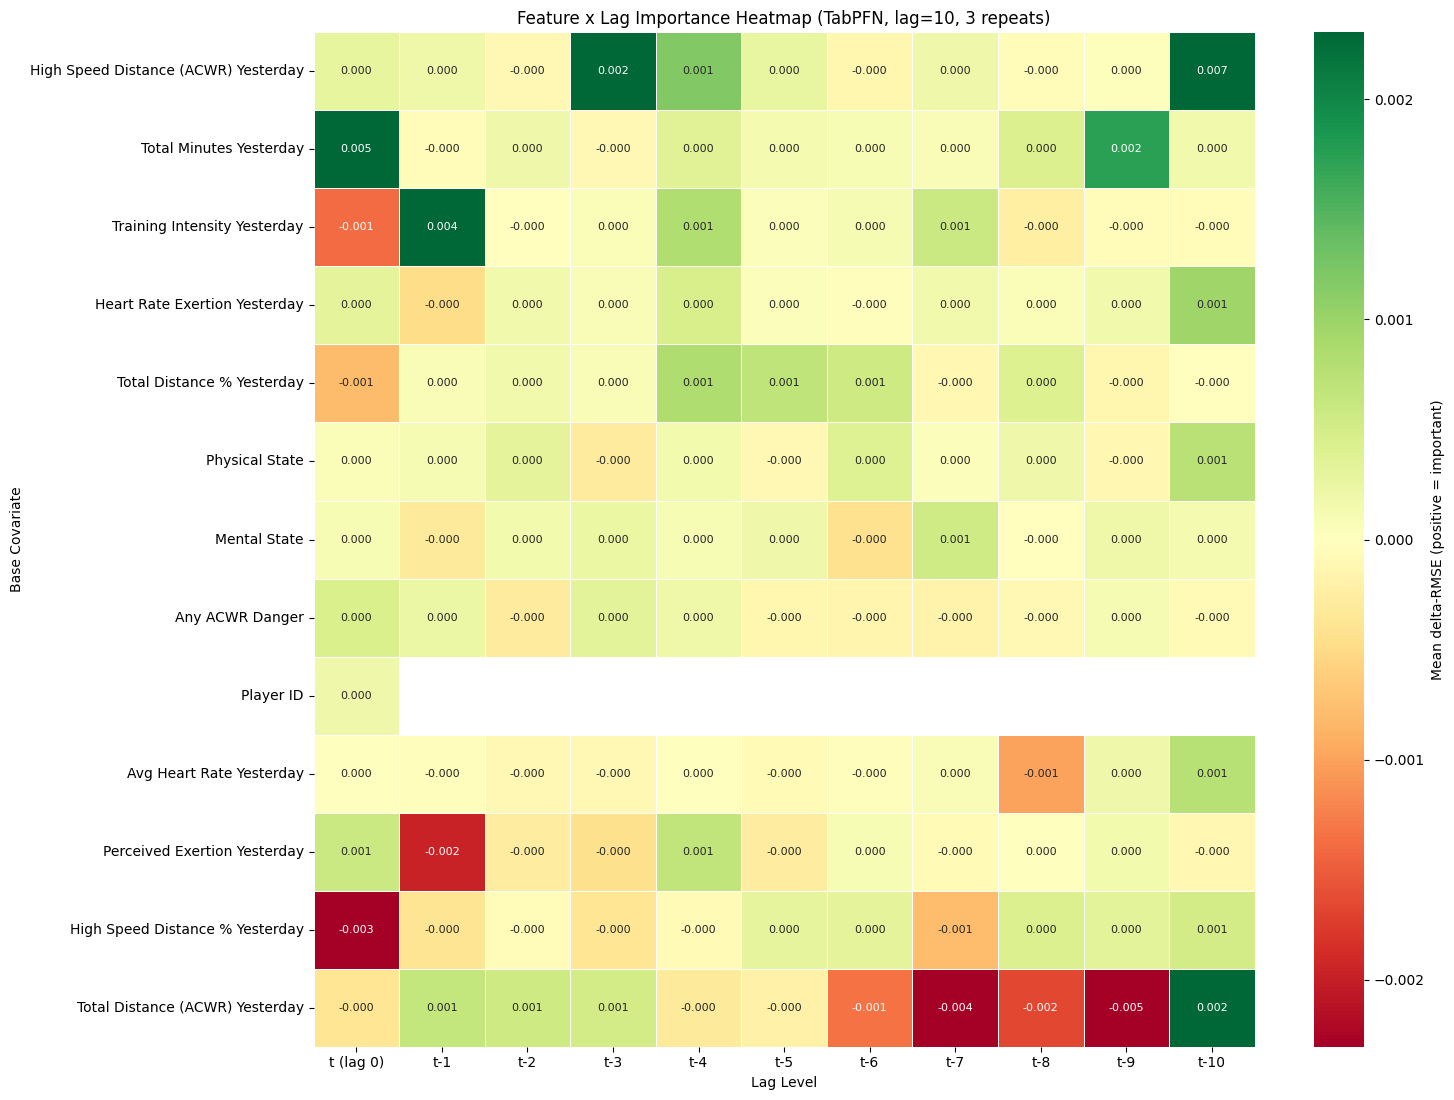

In [16]:
# -- Feature x Lag Importance Heatmap ------------------------------------------
# Compute PER-FEATURE permutation importance (3 repeats, lightweight) to show
# how importance varies across lag copies. The group-level analysis (cell above)
# shuffles all copies together; this cell shuffles each column individually.
from tqdm import tqdm
print('Computing per-feature permutation importance for heatmap (3 repeats)...')

N_REPEATS_HM = 3
rng_hm = np.random.default_rng(seed=99)
perm_deltas_per_feat = {}

for j, feat in enumerate(tqdm(feat_names_6, desc="Per-feature importance")):
    deltas = []
    for _ in range(N_REPEATS_HM):
        X_perm = X_test_6.copy()
        X_perm[:, j] = rng_hm.permutation(X_perm[:, j])
        y_pp = tfn_6.predict(X_perm)
        deltas.append(float(np.sqrt(np.mean((y_test_6 - y_pp) ** 2))) - bl_rmse_6)
    perm_deltas_per_feat[feat] = deltas

# Build heatmap: base_group x lag_k
heatmap_raw = {}
for feat, deltas in perm_deltas_per_feat.items():
    bn = base_group_6(feat)
    m_lag = re.search(r'_t-(\d+)$', feat)
    lag_k = int(m_lag.group(1)) if m_lag else 0
    heatmap_raw.setdefault(bn, {}).setdefault(lag_k, []).append(np.mean(deltas))

heatmap_data = {
    bn: {lag_k: np.mean(vals) for lag_k, vals in lag_dict.items()}
    for bn, lag_dict in heatmap_raw.items()
}

all_lag_cols = sorted({k for d in heatmap_data.values() for k in d.keys()})
hm_df = pd.DataFrame(heatmap_data).T.reindex(columns=all_lag_cols, fill_value=np.nan)
col_labels_hm = ['t (lag 0)' if k == 0 else f't-{k}' for k in all_lag_cols]
hm_df.columns = col_labels_hm
hm_df = hm_df.loc[hm_df.sum(axis=1).sort_values(ascending=False).index]

print('Heatmap values (mean delta-RMSE per feature x lag):')
print(hm_df.round(4).to_string())

valid_vals = hm_df.values[~np.isnan(hm_df.values)]
vmax_hm = float(np.percentile(np.abs(valid_vals), 95)) if len(valid_vals) > 0 else 0.05
vmax_hm = max(vmax_hm, 0.001)

fig_h = max(4, len(hm_df) * 0.7 + 2)
fig_w = max(8, len(col_labels_hm) * 1.1 + 3)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(
    hm_df, ax=ax, cmap='RdYlGn', center=0, vmin=-vmax_hm, vmax=vmax_hm,
    annot=True, fmt='.3f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Mean delta-RMSE (positive = important)'},
)
ax.set_xlabel('Lag Level')
ax.set_ylabel('Base Covariate')
ax.set_title(f'Feature x Lag Importance Heatmap (TabPFN, lag={best_tfn_lag}, {N_REPEATS_HM} repeats)')
plt.tight_layout()
plt.show()



=== § 7.6 — Covariate Redundancy Analysis ===

Base features for redundancy analysis (13):
  Physical State
  Mental State
  Training Intensity Yesterday
  Total Distance (ACWR) Yesterday
  High Speed Distance (ACWR) Yesterday
  Any ACWR Danger
  Total Distance % Yesterday
  High Speed Distance % Yesterday
  Perceived Exertion Yesterday
  Total Minutes Yesterday
  Avg Heart Rate Yesterday
  Heart Rate Exertion Yesterday
  Player ID

(Player ID = label-encoded integer 0-22 for correlation purposes only — NOT used as a numeric feature in TabPFN)

=== Variance Inflation Factors (VIF) ===
VIF > 10: high multicollinearity  |  VIF > 5: moderate  |  VIF < 5: low
Note: Player ID is a nominal category — its VIF has a different interpretation
      (high VIF for Player ID reflects that it is correlated with other features,
       not that its integer encoding implies ordinal multicollinearity.)

  Total Distance (ACWR) Yesterday                       VIF = 100.00  ⚠ HIGH
  High Speed Distance (A

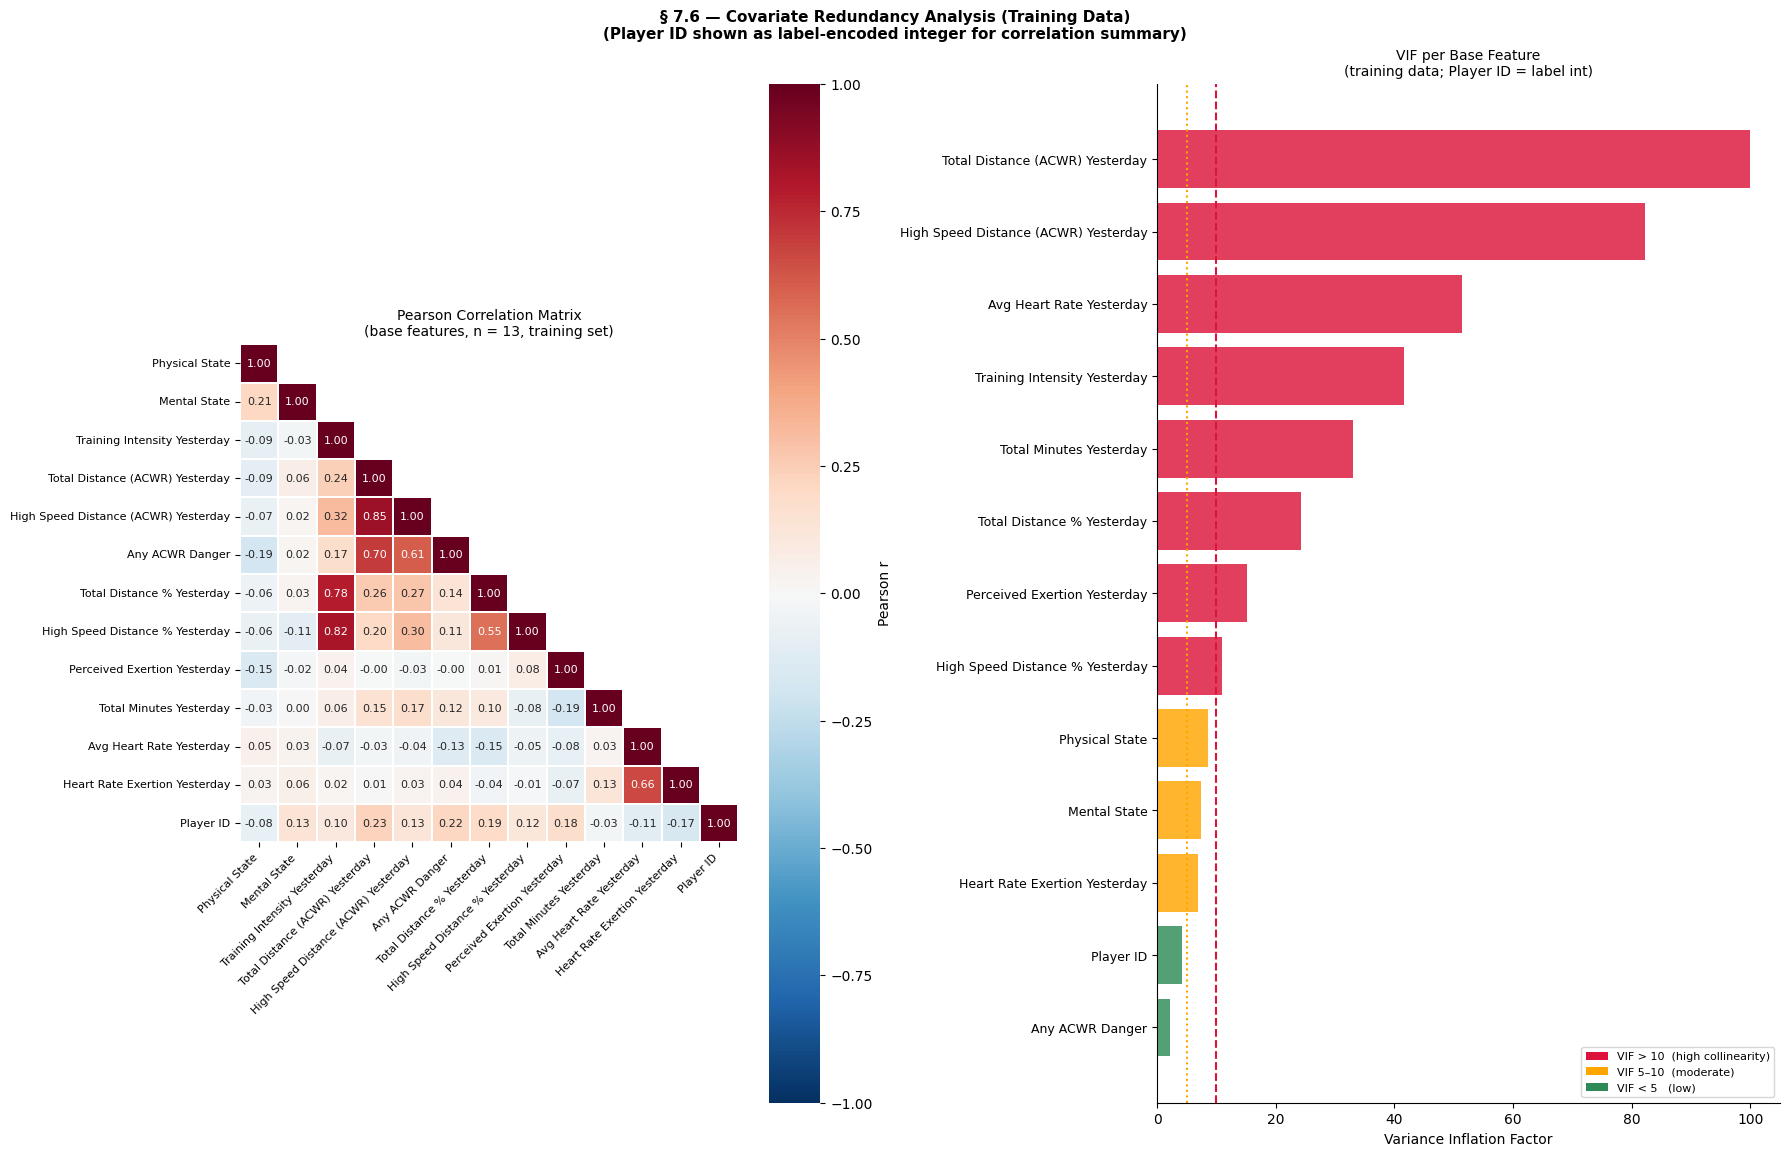


=== Highly Correlated Feature Pairs (|r| > 0.70) ===
  Total Distance (ACWR) Yesterday  ↔  High Speed Distance (ACWR) Yesterday:  r = 0.852
  Training Intensity Yesterday  ↔  High Speed Distance % Yesterday:  r = 0.822
  Training Intensity Yesterday  ↔  Total Distance % Yesterday:  r = 0.782

Highly correlated features carry redundant information. Pruning one from each pair is unlikely to hurt predictive performance.


In [17]:
# ── § 7.6 Covariate Redundancy Analysis ──────────────────────────────────────
# Part A: Pearson correlation matrix between base features (training data)
# Part B: Variance Inflation Factor (VIF) — detects multicollinearity
#
# Note on Player ID:
#   Player ID was one-hot encoded (28 binary indicators) in § 7.1.
#   Including 28 binary columns in a Pearson correlation matrix is noisy and
#   not meaningful for a redundancy check (each indicator only ever equals 0 or 1).
#   Instead, we load a separate label-encoded version of Player ID (integer 0-27)
#   for the correlation analysis — this represents the identity in a single column
#   and gives a sensible correlation with the other continuous covariates.
print('=== § 7.6 — Covariate Redundancy Analysis ===\n')

# ── Load a label-encoded version of the training data for redundancy analysis ─
loader_r = ReadinessDataLoader()
data_r = loader_r.create_dataset(
    target_variable='Match Intensity Yesterday',
    predictory_columns=COVARIATES,
    lag=best_tfn_lag,
    target_horizon=1,
    test_size=0.2,
    val_size=0.1,
    categorical_encoding='label',   # label-encode so Player ID is 1 integer column
    standardize=False,
    missing_numeric='mean',
    missing_categorical='mode',
)
train_lbl_df = data_r['X_train'].copy()
train_lbl_df.columns = data_r['feature_names']

# ── Select base (lag-0) features; these are the current-row columns, no _t-k ──
base_feat_cols_r = [f for f in data_r['feature_names']
                    if not re.search(r'_t-\d+$', f)]
if len(base_feat_cols_r) < 2:
    base_feat_cols_r = list(data_r['feature_names'])

print(f'Base features for redundancy analysis ({len(base_feat_cols_r)}):')
for c in base_feat_cols_r:
    print(f'  {c}')
print(f'\n(Player ID = label-encoded integer 0-{train_lbl_df["Player ID"].max():.0f}'
      f' for correlation purposes only — NOT used as a numeric feature in TabPFN)')

corr_mat_r = train_lbl_df[base_feat_cols_r].corr(method='pearson')

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(base_feat_cols_r) * 0.75 + 2)))
fig.suptitle('§ 7.6 — Covariate Redundancy Analysis (Training Data)\n'
             '(Player ID shown as label-encoded integer for correlation summary)',
             fontsize=11, fontweight='bold')

# Panel A: Correlation heatmap (lower triangle only)
ax = axes[0]
mask_upper = np.triu(np.ones_like(corr_mat_r, dtype=bool), k=1)
sns.heatmap(
    corr_mat_r, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    mask=mask_upper, square=True,
    linewidths=0.35, linecolor='white',
    cbar_kws={'label': 'Pearson r'},
)
ax.set_title(f'Pearson Correlation Matrix\n'
             f'(base features, n = {len(base_feat_cols_r)}, training set)',
             fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Panel B: VIF bar chart
ax = axes[1]
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif_data = train_lbl_df[base_feat_cols_r].dropna()
    vif_vals = {}
    if len(vif_data) > len(base_feat_cols_r) + 1:
        for i, col in enumerate(base_feat_cols_r):
            try:
                vif_vals[col] = min(variance_inflation_factor(vif_data.values, i), 100.0)
            except Exception:
                vif_vals[col] = np.nan

    vif_s = pd.Series(vif_vals).sort_values(ascending=False)
    print('\n=== Variance Inflation Factors (VIF) ===')
    print('VIF > 10: high multicollinearity  |  VIF > 5: moderate  |  VIF < 5: low')
    print('Note: Player ID is a nominal category — its VIF has a different interpretation')
    print('      (high VIF for Player ID reflects that it is correlated with other features,')
    print('       not that its integer encoding implies ordinal multicollinearity.)\n')
    for feat_v, val_v in vif_s.items():
        flag = '  ⚠ HIGH' if val_v > 10 else ('  ▲ mod.' if val_v > 5 else '')
        pid_flag = '  [nominal — see note]' if 'Player ID' in feat_v else ''
        print(f'  {feat_v:52s}  VIF = {val_v:6.2f}{flag}{pid_flag}')

    colors_vif = ['crimson' if v > 10 else ('orange' if v > 5 else 'seagreen')
                  for v in vif_s.values]
    ax.barh(range(len(vif_s)), vif_s.values[::-1], color=colors_vif[::-1], alpha=0.82)
    ax.set_yticks(range(len(vif_s)))
    ax.set_yticklabels(list(vif_s.index[::-1]), fontsize=9)
    ax.axvline(10, color='crimson', linestyle='--', lw=1.5)
    ax.axvline(5,  color='orange',  linestyle=':',  lw=1.5)
    ax.set_xlabel('Variance Inflation Factor')
    ax.set_title('VIF per Base Feature\n(training data; Player ID = label int)', fontsize=10)
    legend_vif = [
        Patch(facecolor='crimson',  label='VIF > 10  (high collinearity)'),
        Patch(facecolor='orange',   label='VIF 5–10  (moderate)'),
        Patch(facecolor='seagreen', label='VIF < 5   (low)'),
    ]
    ax.legend(handles=legend_vif, fontsize=8)
except ImportError:
    ax.text(0.5, 0.5, 'statsmodels not installed.\nRun: pip install statsmodels',
            ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
    print('VIF skipped: statsmodels not installed. Run: pip install statsmodels')

plt.tight_layout()
plt.show()

# ── High-correlation summary ────────────────────────────────────────────────
print('\n=== Highly Correlated Feature Pairs (|r| > 0.70) ===')
high_pairs = []
cols_r = corr_mat_r.columns.tolist()
for i in range(len(cols_r)):
    for j in range(i + 1, len(cols_r)):
        r_ij = corr_mat_r.iloc[i, j]
        if abs(r_ij) > 0.70:
            high_pairs.append((cols_r[i], cols_r[j], r_ij))
if high_pairs:
    for fa, fb, r_v in sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {fa}  ↔  {fb}:  r = {r_v:.3f}')
    print('\nHighly correlated features carry redundant information. '
          'Pruning one from each pair is unlikely to hurt predictive performance.')
else:
    print('  No feature pairs with |r| > 0.70 detected — low linear redundancy.')



---
## 3. Experiment B — Match Intensity Personal Deviation

Experiment A showed apparent predictive power (R² ≈ 0.27) but feature importance revealed Player ID as the dominant driver. To test whether there is signal *beyond* player identity, we define:

**Match Intensity Personal Deviation** = player’s match intensity − their own expanding-mean baseline.

This removes the player fixed effect entirely: the model must predict whether a player performs above or below *their own average*.


In [18]:
# ── § 1 — Match Intensity Personal Deviation: All Models × All Lags ─────────
# Target  : 'Match Intensity Personal Deviation'  (target_horizon=0)
#   = current match intensity − player's expanding-mean baseline
#   Filled only on match days where the player participated AND has ≥1 prior match.
#
# run_experiment() forwards extra kwargs to the model constructor, which passes
# them to the data loader. Overriding target_variable and target_horizon here
# is safe — they overwrite the Experiment A defaults in _build_model().
#
# Covariates: same as Experiment A + 'Match Intensity Personal Average'
# (the rolling baseline that defines the deviation — highly informative prior).
#
# ⚠ Dataset is very small (~600 match-day rows total, ~80–120 test rows).
# Results are noisy; look for consistent directional patterns across lags/models.

COVARIATES_DEV = COVARIATES + ['Match Intensity Personal Average']

dev_model_types = {
    'LinReg':   'lin_reg',
    'XGBoost':  'xgboost',
    'CatBoost': 'catboost',
    'TabPFN':   'tabpfn',
}
dev_results = {name: {} for name in dev_model_types}

for model_name, model_type in dev_model_types.items():
    print(f'\n{"="*62}')
    print(f'  {model_name} — Match Intensity Personal Deviation')
    print(f'{"="*62}')
    for lag in LAGS:
        try:
            r = run_experiment(
                covariates=COVARIATES_DEV,
                lag=lag,
                model_type=model_type,
                target_variable='Match Intensity Personal Deviation',
                target_horizon=0,   # deviation lives on the match day itself
                test_size=0.2,
                val_size=0.1,
                verbose=False,
                **GPU_OVERRIDES.get(model_type, {}),
            )
            dev_results[model_name][lag] = r
            m = r['metrics']
            flag = '✓' if m['rmse'] < m['null_rmse'] else '✗'
            print(f'  lag={lag:2d} {flag}  RMSE={m["rmse"]:.4f}  '
                  f'Null={m["null_rmse"]:.4f}  R²={m["r2"]:+.3f}  '
                  f'Pearson r={m["pearson_r"]:+.3f}  N={m["n_test"]}')
        except Exception as e:
            dev_results[model_name][lag] = None
            print(f'  lag={lag:2d} ✗  ERROR: {e}')
    print()




  LinReg — Match Intensity Personal Deviation
  lag= 1 ✗  RMSE=0.9481  Null=0.9350  R²=-0.066  Pearson r=+0.076  N=72
  lag= 2 ✗  RMSE=0.9565  Null=0.9350  R²=-0.085  Pearson r=+0.034  N=72
  lag= 3 ✗  RMSE=0.9654  Null=0.9350  R²=-0.105  Pearson r=-0.012  N=72
  lag= 4 ✗  RMSE=0.9673  Null=0.9350  R²=-0.110  Pearson r=+0.037  N=72
  lag= 5 ✗  RMSE=0.9654  Null=0.9350  R²=-0.105  Pearson r=+0.057  N=72
  lag= 6 ✗  RMSE=0.9641  Null=0.9350  R²=-0.102  Pearson r=+0.089  N=72
  lag= 7 ✗  RMSE=0.9568  Null=0.9350  R²=-0.086  Pearson r=+0.113  N=72
  lag= 8 ✗  RMSE=0.9638  Null=0.9350  R²=-0.102  Pearson r=+0.100  N=72
  lag= 9 ✗  RMSE=0.9690  Null=0.9350  R²=-0.113  Pearson r=+0.084  N=72
  lag=10 ✗  RMSE=0.9537  Null=0.9350  R²=-0.079  Pearson r=+0.152  N=72


  XGBoost — Match Intensity Personal Deviation
  lag= 1 ✓  RMSE=0.9333  Null=0.9350  R²=-0.033  Pearson r=+0.168  N=72
  lag= 2 ✗  RMSE=0.9529  Null=0.9350  R²=-0.077  Pearson r=-0.110  N=72
  lag= 3 ✗  RMSE=0.9455  Null=0.9350  R²

  lag= 1 ✗  RMSE=0.9391  Null=0.9350  R²=-0.046  Pearson r=-0.153  N=72


  lag= 2 ✗  RMSE=0.9369  Null=0.9350  R²=-0.041  Pearson r=+0.026  N=72


  lag= 3 ✗  RMSE=0.9388  Null=0.9350  R²=-0.045  Pearson r=-0.207  N=72


  lag= 4 ✗  RMSE=0.9385  Null=0.9350  R²=-0.045  Pearson r=-0.028  N=72


...

  lag= 6 ✗  RMSE=0.9358  Null=0.9350  R²=-0.039  Pearson r=-0.244  N=72


  lag= 7 ✗  RMSE=0.9364  Null=0.9350  R²=-0.040  Pearson r=+0.018  N=72


  lag= 8 ✗  RMSE=0.9444  Null=0.9350  R²=-0.058  Pearson r=+0.085  N=72


  lag= 9 ✗  RMSE=0.9632  Null=0.9350  R²=-0.100  Pearson r=-0.043  N=72


  lag=10 ✗  RMSE=0.9431  Null=0.9350  R²=-0.055  Pearson r=+0.046  N=72


  TabPFN — Match Intensity Personal Deviation
  lag= 1 ✗  RMSE=0.9947  Null=0.9350  R²=-0.173  Pearson r=+0.116  N=72
  lag= 2 ✗  RMSE=1.0033  Null=0.9350  R²=-0.194  Pearson r=+0.097  N=72
  lag= 3 ✗  RMSE=0.9897  Null=0.9350  R²=-0.162  Pearson r=+0.110  N=72
  lag= 4 ✗  RMSE=0.9949  Null=0.9350  R²=-0.174  Pearson r=+0.091  N=72
  lag= 5 ✗  RMSE=0.9749  Null=0.9350  R²=-0.127  Pearson r=+0.121  N=72
  lag= 6 ✗  RMSE=0.9799  Null=0.9350  R²=-0.139  Pearson r=+0.135  N=72
  lag= 7 ✗  RMSE=0.9837  Null=0.9350  R²=-0.147  Pearson r=+0.138  N=72
  lag= 8 ✗  RMSE=0.9704  Null=0.9350  R²=-0.117  Pearson r=+0.165  N=72
  lag= 9 ✗  RMSE=0.9799  Null=0.9350  R²=-0.139  Pearson r=+0.127  N=72
  lag=10 ✓  RMSE=0.9302  Null=0.9350  R²=-0.026  Pearson r=+0.267  N=72



=== § 1 — Deviation Prediction: Full Results ===
   Model  Lag   RMSE  Null RMSE      R²  Pearson r  N test  Beats Null
CatBoost    1 0.9391      0.935 -0.0459    -0.1527      72       False
CatBoost    2 0.9369      0.935 -0.0409     0.0263      72       False
CatBoost    3 0.9388      0.935 -0.0453    -0.2074      72       False
CatBoost    4 0.9385      0.935 -0.0446    -0.0282      72       False
CatBoost    5 0.9534      0.935 -0.0779    -0.1588      72       False
CatBoost    6 0.9358      0.935 -0.0386    -0.2437      72       False
CatBoost    7 0.9364      0.935 -0.0398     0.0185      72       False
CatBoost    8 0.9444      0.935 -0.0576     0.0847      72       False
CatBoost    9 0.9632      0.935 -0.1002    -0.0434      72       False
CatBoost   10 0.9431      0.935 -0.0548     0.0465      72       False
  LinReg    1 0.9481      0.935 -0.0659     0.0757      72       False
  LinReg    2 0.9565      0.935 -0.0849     0.0339      72       False
  LinReg    3 0.9654      0.

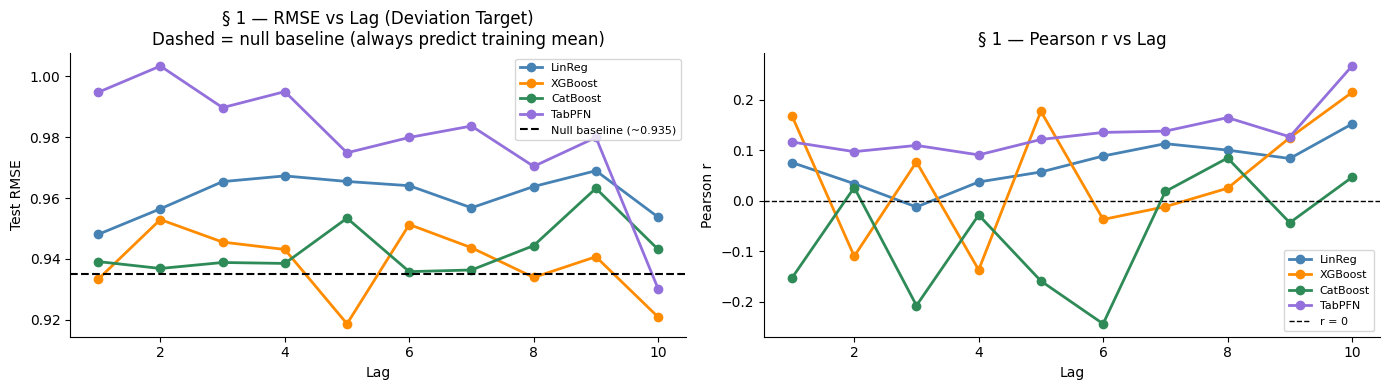


────────────────────────────────────────────────────────────
Interpretation:
  5/40 model-lag combinations beat the null baseline.
  Null RMSE ≈ std(deviation) — i.e. predicting the mean is as good as
  predicting zero deviation for every match.
  RMSE < Null RMSE: the model extracts genuine within-player signal.
  R² < 0: model is worse than a constant predictor (common for sparse data).
  Compare with Experiment A (§ 2–§ 6): absolute intensity vs deviation.
────────────────────────────────────────────────────────────


In [19]:
# ── § 1 — Deviation Summary: RMSE vs Lag + best-lag table ───────────────────
dev_rows = []
for model_name, res_by_lag in dev_results.items():
    for lag, r in res_by_lag.items():
        if r is None:
            continue
        m = r['metrics']
        dev_rows.append({
            'Model': model_name,
            'Lag': lag,
            'RMSE': round(m['rmse'], 4),
            'Null RMSE': round(m['null_rmse'], 4),
            'R²': round(m['r2'], 4),
            'Pearson r': round(m['pearson_r'], 4),
            'N test': m['n_test'],
            'Beats Null': m['rmse'] < m['null_rmse'],
        })

if not dev_rows:
    print("No results to summarise.")
else:
    dev_summary_df = pd.DataFrame(dev_rows).sort_values(['Model', 'Lag']).reset_index(drop=True)

    dev_best = (
        dev_summary_df
        .loc[dev_summary_df.groupby('Model')['RMSE'].idxmin()]
        [['Model', 'Lag', 'RMSE', 'Null RMSE', 'R²', 'Pearson r', 'N test']]
        .sort_values('RMSE')
        .reset_index(drop=True)
    )

    print('=== § 1 — Deviation Prediction: Full Results ===')
    print(dev_summary_df.to_string(index=False))
    print('\n=== Best Lag per Model (lowest Test RMSE) ===')
    print(dev_best.to_string(index=False))

    # ── RMSE vs Lag + Pearson r vs Lag ───────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    null_vals_by_model = {}
    for model_name, res_by_lag in dev_results.items():
        lags_ok = sorted(l for l, r in res_by_lag.items() if r is not None)
        if not lags_ok:
            continue
        rmses  = [dev_results[model_name][l]['metrics']['rmse']      for l in lags_ok]
        pr     = [dev_results[model_name][l]['metrics']['pearson_r']  for l in lags_ok]
        nulls  = [dev_results[model_name][l]['metrics']['null_rmse']  for l in lags_ok]
        null_vals_by_model[model_name] = np.mean(nulls)
        col = MODEL_PALETTE.get(model_name, 'gray')
        ax1.plot(lags_ok, rmses, marker='o', label=model_name, color=col, linewidth=2)
        ax2.plot(lags_ok, pr,    marker='o', label=model_name, color=col, linewidth=2)

    if null_vals_by_model:
        null_mean = np.mean(list(null_vals_by_model.values()))
        ax1.axhline(null_mean, color='black', linestyle='--', linewidth=1.5,
                    label=f'Null baseline (~{null_mean:.3f})')
    ax2.axhline(0, color='black', linestyle='--', linewidth=1, label='r = 0')

    ax1.set(xlabel='Lag', ylabel='Test RMSE',
            title='§ 1 — RMSE vs Lag (Deviation Target)\n'
                  'Dashed = null baseline (always predict training mean)')
    ax2.set(xlabel='Lag', ylabel='Pearson r',
            title='§ 1 — Pearson r vs Lag')
    for ax in (ax1, ax2):
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Interpretation ────────────────────────────────────────────────────────
    n_beats = sum(1 for r in dev_rows if r['Beats Null'])
    print(f'\n{"─"*60}')
    print(f'Interpretation:')
    print(f'  {n_beats}/{len(dev_rows)} model-lag combinations beat the null baseline.')
    print(f'  Null RMSE ≈ std(deviation) — i.e. predicting the mean is as good as')
    print(f'  predicting zero deviation for every match.')
    print(f'  RMSE < Null RMSE: the model extracts genuine within-player signal.')
    print(f'  R² < 0: model is worse than a constant predictor (common for sparse data).')
    print(f'  Compare with Experiment A (§ 2–§ 6): absolute intensity vs deviation.')
    print(f'{"─"*60}')



---
## 4. Summary


In [20]:
try:
    print("=" * 72)
    print("EXPERIMENT 1 -- RESULTS SUMMARY")
    print("=" * 72)
    print()

    # --- Experiment A: Raw Match Intensity ---
    rtp = {'LinReg': linreg_results, 'XGBoost': xgb_results,
           'CatBoost': cat_results, 'TabPFN': tabpfn_results}
    print("EXPERIMENT A -- RAW MATCH INTENSITY")
    print("-" * 72)
    print(f"  {'Model':<12} {'Lag':>4} {'RMSE':>8} {'Null':>8} {'R2':>8} {'r':>8} {'MAE':>8} {'TrRMSE':>8} {'N':>5}")
    for mn, mr in rtp.items():
        for lag in LAGS:
            r = mr.get(lag)
            if r is None: continue
            m = r['metrics']
            print(f"  {mn:<12} {lag:>4} {m['rmse']:>8.4f} {m['null_rmse']:>8.4f} "
                  f"{m['r2']:>8.4f} {m['pearson_r']:>8.4f} {m['mae']:>8.4f} "
                  f"{m['train_rmse']:>8.4f} {m['n_test']:>5}")
    print()
    ac = [(mn, l) for mn, mr in rtp.items() for l in LAGS if mr.get(l)]
    if ac:
        bn, bl = min(ac, key=lambda ml: rtp[ml[0]][ml[1]]['metrics']['rmse'])
        bm = rtp[bn][bl]['metrics']
        print(f"BEST (Exp A): {bn} lag={bl}")
        for k, v in bm.items():
            if isinstance(v, float):
                print(f"  {k:<20} {v:.6f}")
            else:
                print(f"  {k:<20} {v}")

    # --- Per-player metrics ---
    print()
    print("PER-PLAYER METRICS (best Exp A model)")
    print("-" * 72)
    if ac:
        best_res = rtp[bn][bl]
        pp = best_res.get('per_player', {})
        if pp:
            for pid, v in sorted(pp.items()):
                r2_str = f"{v['r2']:.4f}" if v.get('r2') is not None else "N/A"
                print(f"  Player {str(pid):<8}  N={v['n']:>4}  RMSE={v['rmse']:.4f}  R2={r2_str}")

    # --- Permutation importance ---
    print()
    print("GROUP PERMUTATION IMPORTANCE (TabPFN)")
    print("-" * 72)
    try:
        for bn_p in perm_mean_6.index:
            print(f"  {bn_p:52s}  {perm_mean_6[bn_p]:+.4f} +/- {perm_sem_6[bn_p]:.4f}")
    except NameError:
        print("  (not computed)")

    # --- Experiment B: Personal Deviation ---
    print()
    print("EXPERIMENT B -- MATCH INTENSITY PERSONAL DEVIATION")
    print("-" * 72)
    try:
        print(f"  {'Model':<12} {'Lag':>4} {'RMSE':>8} {'Null':>8} {'R2':>8}")
        for mn, mr in dev_results.items():
            for lag in sorted(mr.keys()):
                r = mr[lag]
                if r is None: continue
                m = r['metrics']
                print(f"  {mn:<12} {lag:>4} {m['rmse']:>8.4f} {m['null_rmse']:>8.4f} {m['r2']:>8.4f}")
        print()
        # Best per model
        print("  BEST PER MODEL (Exp B):")
        for mn, mr in dev_results.items():
            valid = [(l, r) for l, r in mr.items() if r is not None]
            if valid:
                best_l, best_r = min(valid, key=lambda lr: lr[1]['metrics']['rmse'])
                m = best_r['metrics']
                print(f"    {mn:<12}  lag={best_l}  RMSE={m['rmse']:.4f}  Null={m['null_rmse']:.4f}  R2={m['r2']:.4f}")
    except NameError:
        print("  (Experiment B not run)")

    print()
    print("=" * 72)

except NameError:
    print("[Summary] Run experiment cells first.")



EXPERIMENT 1 -- RESULTS SUMMARY

EXPERIMENT A -- RAW MATCH INTENSITY
------------------------------------------------------------------------
  Model         Lag     RMSE     Null       R2        r      MAE   TrRMSE     N
  LinReg          1   1.1142   1.3820   0.2658   0.7228   0.9251   0.6425    72
  LinReg          2   1.2646   1.3820   0.0542   0.6833   1.0332   0.5997    72
  LinReg          3   1.2854   1.3820   0.0228   0.6162   1.0175   0.6395    72
  LinReg          4   1.2735   1.3820   0.0409   0.5727   0.9917   0.6705    72
  LinReg          5   1.2782   1.3820   0.0338   0.5503   0.9934   0.6670    72
  LinReg          6   1.2628   1.3820   0.0568   0.5936   0.9889   0.6285    72
  LinReg          7   1.2389   1.3820   0.0923   0.5252   0.9670   0.6378    72
  LinReg          8   1.2739   1.3820   0.0403   0.4872   0.9982   0.6825    72
  LinReg          9   1.3115   1.3820  -0.0172   0.4288   1.0329   0.8034    72
  LinReg         10   1.3064   1.3820  -0.0094   0.4851   